## R语言的分析

ℹ️ Mac环境提示：安装「Arial Unicode MS」可解决中文方框问题
✅ 中文显示配置完成！
✅ 数据源路径验证通过：/Users/wangguotao/Downloads/ISAR/Doctor/数据分析总表.xlsx
✅ 路径与变量定义完成！
✅ 成功读取数据：143行 × 99列
✅ 缺失值统计已保存

📊 数据概况：
   - 总样本：143例
   - 外科组：117例
   - 内镜组：26例
   - 缓解率：90.9%

✅ 单因素分析结果已保存

📊 变量分类统计：
   • 剔除变量：13个
   • 核心变量：4个
   • 敏感性变量：2个
   • 关键变量：1个
   • DR变量：1个

✅ VIF候选变量：lesion_location、lesion_max_diameter_mm、walled_necrosis、modified_ctsi_score、bmi、apache2、comorbidity_hypertension（共7个）
1. 保留 modified_ctsi_score（核心变量）
2. 保留 bmi
4. 保留 lesion_location（VIF=1.02413028885017）
4. 保留 lesion_max_diameter_mm（VIF=1.03306949646479）
4. 保留 walled_necrosis（VIF=2.38091588497088）
4. 保留 apache2（VIF=1.17898931035564）
4. 保留 comorbidity_hypertension（VIF=1.16873248032315）

🎉 最终PS模型变量：modified_ctsi_score、bmi、lesion_location、lesion_max_diameter_mm、walled_necrosis、apache2、comorbidity_hypertension（共7个）
🎯 DR模型变量：gallstone（共1个）
✅ VIF检验结果已保存

✅ PS建模样本：120例（外科组：94例）


Setting levels: control = 0, case = 1

Setting direction: controls < cases



📊 PS模型AUC：0.734（>0.7为良好）

🎯 匹配结果：11对，平衡变量0/7（0%）
✅ PS结果已保存


Setting levels: control = 0, case = 1

Setting direction: controls < cases




📌 模型稳定性：完整AUC=0.734，核心AUC=0.628（不稳定）

📌 阈值鲁棒性：
   - 卡尺0.05：7对（保留率7.4%）
   - 卡尺0.1：11对（保留率11.7%）
   - 卡尺0.15：12对（保留率12.8%）

📌 双稳健估计：OR=1.74（内镜组缓解率更高）

✅ 敏感性分析结果已保存

📊 生成可视化图表...
✅ 变量分类饼图已保存


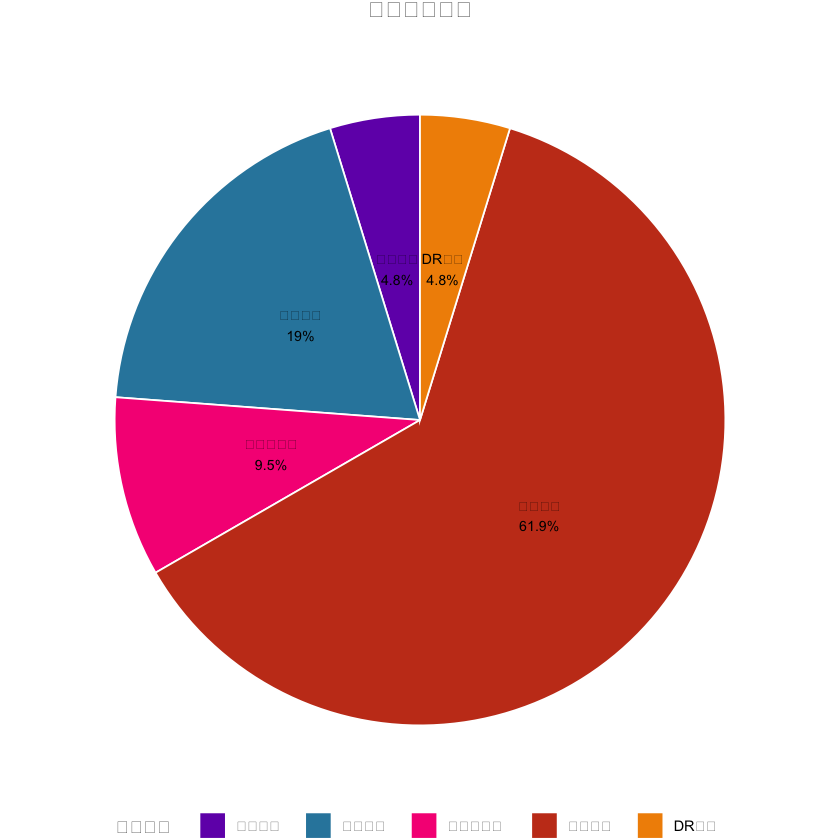

✅ PS值分布图已保存


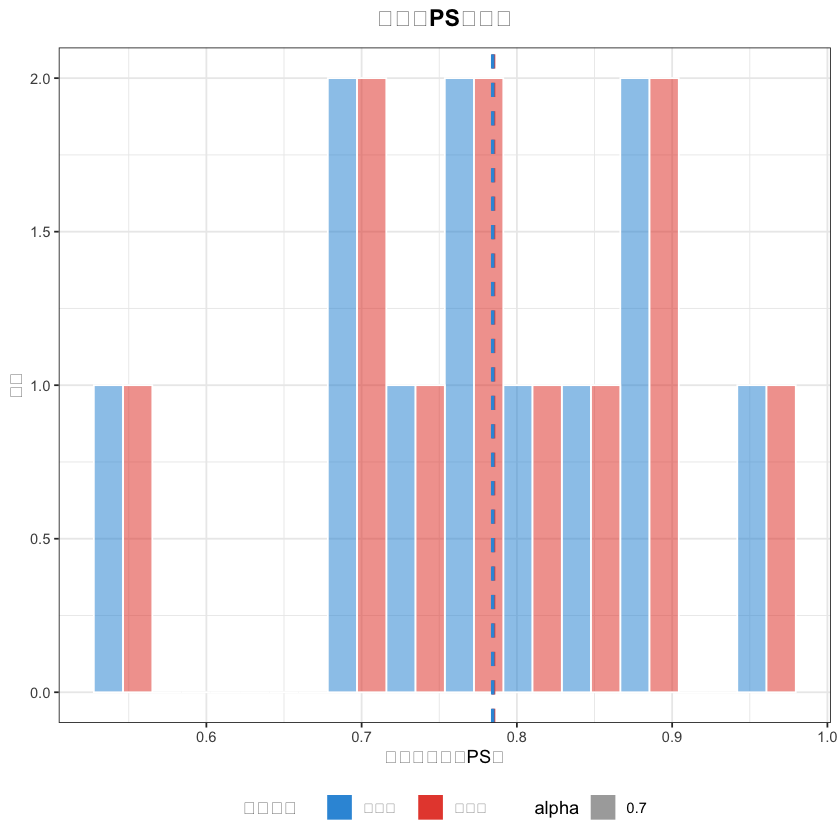

✅ 样本量对比图已保存
✅ 分析报告已保存

🎉 所有分析流程完成！
📁 结果文件位置：/Users/wangguotao/bp-ai-api/AndyBourne-Blog/posts/Test/R_分析结果
💡 核心提示：
   - 匹配后数据： 11 对（ 22 例），可通过`matched_data`调用
   - 后续分析：复制报告中代码，直接运行获取结局统计结果

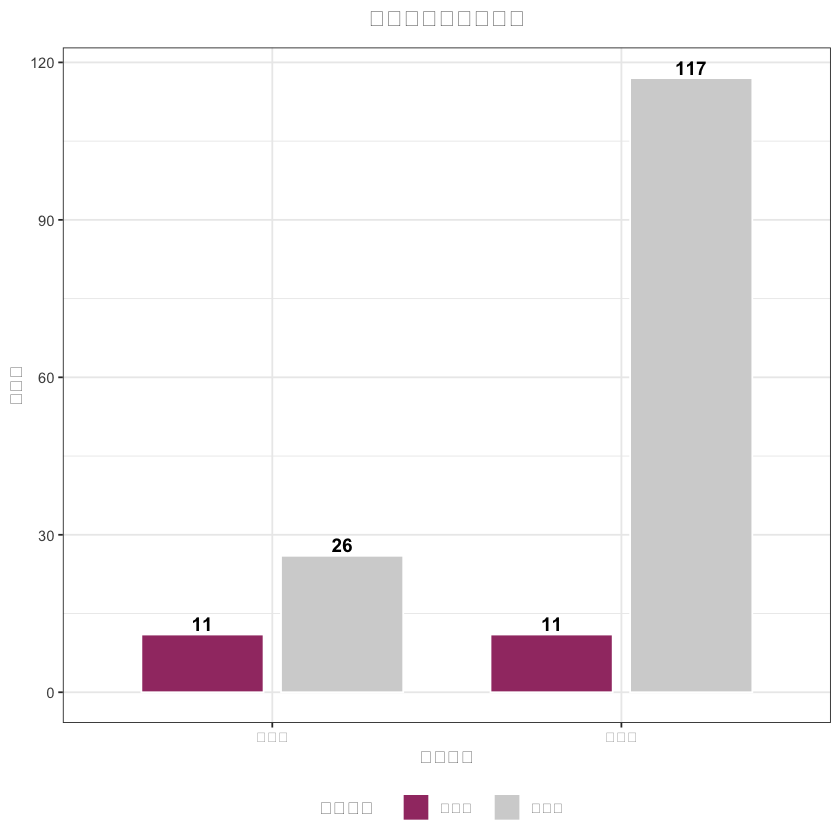

In [49]:
# 清除环境变量
rm(list = ls())

# 安装必需包（首次运行时取消注释执行，后续注释；仅核心包）
# install.packages(c("readxl", "writexl", "dplyr", "tidyr", "ggplot2", 
#                    "car", "pROC", "MatchIt", "WeightIt", "tableone", 
#                    "corrplot", "stringr"))

# 加载包（无冗余依赖）
library(readxl)       # Excel读写
library(writexl)      # Excel保存
library(dplyr)        # 基础数据清洗
library(tidyr)        # 基础数据重塑
library(ggplot2)      # 可视化
library(car)          # VIF计算
library(pROC)         # ROC/AUC分析
library(MatchIt)      # 倾向性评分匹配
library(WeightIt)     # A-IPTW加权
library(tableone)     # 基线平衡表
library(corrplot)     # 相关性分析（备用）
library(stringr)      # 字符串处理

# ======================== 1. 中文显示配置 ========================
if (Sys.info()["sysname"] == "Windows") {
  if ("SimHei" %in% windowsFonts()) {
    theme_set(theme(text = element_text(family = "SimHei", size = 11)))
  } else {
    theme_set(theme(text = element_text(family = "Microsoft YaHei", size = 11)))
  }
} else {
  theme_set(theme(text = element_text(family = "Arial", size = 11)))
  cat("ℹ️ Mac环境提示：安装「Arial Unicode MS」可解决中文方框问题\n")
}
cat("✅ 中文显示配置完成！\n")

# ======================== 2. 路径配置（已填你的路径，无需改） ========================
DATA_PATH <- "/Users/wangguotao/Downloads/ISAR/Doctor/数据分析总表.xlsx"  
OUTPUT_DIR <- "./R_分析结果/"  

# 创建结果目录
if (!dir.exists(OUTPUT_DIR)) {
  dir.create(OUTPUT_DIR, recursive = TRUE)
  cat(paste0("✅ 自动创建结果目录：", normalizePath(OUTPUT_DIR), "\n"))
}

# 路径验证
if (!file.exists(DATA_PATH)) {
  stop(paste0(
    "❌ 数据源路径不存在！\n",
    "当前路径：", DATA_PATH, "\n",
    "请确认文件位置后修改DATA_PATH"
  ))
} else {
  cat(paste0("✅ 数据源路径验证通过：", DATA_PATH, "\n"))
}

# 变量映射表（基础数据框）
var_mapping <- data.frame(
  原始列名 = c(
    "囊肿位置（1：胰头颈、2：胰体尾4：胰周）", "囊肿最大径mm", "包裹性坏死", 
    "改良CTSI评分", "年龄", "BMI", "性别（1：男、2：女）", "APACHE II评分",
    "重症胰腺炎（1：有2：无）", "病因（1、酒精性2、高甘油三脂血症性3、胆源性4、急性胰腺炎5、慢性胰腺炎6、胰腺手术7、胰腺外伤8、自身免疫性9、特发性）",
    "糖尿病（1、是2、否）", "高血压（1、是2、否）", "高脂血症（1、是2、否）",
    "腹腔积液（1、是2、否）", "门脉高压1：是2：否", "胆囊结石（1、有2、无）",
    "术前白细胞", "吸烟（1、是2、否）", "饮酒（1、是2、否）",
    "影像学缓解（1：是2：否）", "第一次住院总费用", "住院时间",
    "术后感染（1：有2：无）", "复发（1：有 0：无）", "手术方式（1：内镜2：外科）"
  ),
  英文变量名 = c(
    "lesion_location", "lesion_max_diameter_mm", "walled_necrosis", 
    "modified_ctsi_score", "age_years", "bmi", "gender", "apache2",
    "severe_pancreatitis", "etiology", "comorbidity_diabetes", 
    "comorbidity_hypertension", "hyperlipid", "ascites", "portal_htn",
    "gallstone", "wbc_pre", "smoking_history", "drinking_history",
    "imaging_response", "cost_first_hospital", "hospital_stay",
    "complication", "recurrence", "treatment"
  ),
  stringsAsFactors = FALSE
)

core_vars <- c("lesion_location", "lesion_max_diameter_mm", "walled_necrosis", "modified_ctsi_score")
cat("✅ 路径与变量定义完成！\n")

# ======================== 3. 数据读取与预处理 ========================
tryCatch({
  # 读取数据
  df_raw <- read_excel(DATA_PATH, sheet = 1, col_names = TRUE)
  cat(paste0("✅ 成功读取数据：", nrow(df_raw), "行 × ", ncol(df_raw), "列\n"))
  
  # 筛选有效列
  excel_cols <- str_trim(colnames(df_raw))
  valid_idx <- match(var_mapping$原始列名, excel_cols)
  valid_mapping <- var_mapping[!is.na(valid_idx), ]
  
  # 缺失列提示
  missing_cols <- var_mapping$原始列名[is.na(valid_idx)]
  if (length(missing_cols) > 0) {
    cat(paste0("⚠️ 未找到列：", paste(missing_cols[1:3], collapse = "、"), "...\n"))
  }
  
  # 数据重命名
  df_analysis <- df_raw[, match(valid_mapping$原始列名, excel_cols)]
  colnames(df_analysis) <- valid_mapping$英文变量名
  
  # 治疗分组编码
  if ("treatment" %in% colnames(df_analysis)) {
    df_analysis$treatment <- as.numeric(df_analysis$treatment)
    df_analysis <- df_analysis[!is.na(df_analysis$treatment) & df_analysis$treatment %in% c(1, 2), ]
    df_analysis$treatment <- ifelse(df_analysis$treatment == 1, 0, 1)
  } else {
    stop("❌ 未找到「手术方式」列（需包含1=内镜、2=外科）")
  }
  
  # 结局变量编码
  if ("imaging_response" %in% colnames(df_analysis)) {
    df_analysis$imaging_response <- as.numeric(df_analysis$imaging_response)
    df_analysis <- df_analysis[!is.na(df_analysis$imaging_response) & df_analysis$imaging_response %in% c(1, 2), ]
    df_analysis$imaging_response <- ifelse(df_analysis$imaging_response == 1, 1, 0)
  } else {
    stop("❌ 未找到「影像学缓解」列（需包含1=是、2=否）")
  }
  
  # 数值清洗
  for (col in colnames(df_analysis)) {
    if (is.character(df_analysis[[col]])) {
      df_analysis[[col]] <- gsub("[,， 、-]", "", df_analysis[[col]])
      df_analysis[[col]] <- as.numeric(df_analysis[[col]])
    } else {
      df_analysis[[col]] <- as.numeric(df_analysis[[col]])
    }
  }
  
  # 缺失值统计
  missing_count <- apply(df_analysis, 2, function(x) sum(is.na(x)))
  missing_stats <- data.frame(
    变量名 = names(missing_count),
    缺失数量 = as.numeric(missing_count),
    总样本量 = nrow(df_analysis),
    缺失百分比 = round(missing_count / nrow(df_analysis) * 100, 2),
    数据类型 = sapply(df_analysis, function(x) class(x)[1]),
    stringsAsFactors = FALSE
  )
  missing_stats <- missing_stats[order(missing_stats$缺失数量, decreasing = TRUE), ]
  
  write_xlsx(missing_stats, path = paste0(OUTPUT_DIR, "R_缺失值统计.xlsx"))
  cat("✅ 缺失值统计已保存\n")
  
  # 数据概况
  cat(paste0("\n📊 数据概况：\n"))
  cat(paste0("   - 总样本：", nrow(df_analysis), "例\n"))
  cat(paste0("   - 外科组：", sum(df_analysis$treatment == 1, na.rm = TRUE), "例\n"))
  cat(paste0("   - 内镜组：", sum(df_analysis$treatment == 0, na.rm = TRUE), "例\n"))
  cat(paste0("   - 缓解率：", round(mean(df_analysis$imaging_response, na.rm = TRUE) * 100, 1), "%\n"))
  
}, error = function(e) {
  stop(paste0(
    "❌ 数据预处理失败：", e$message, "\n",
    "解决步骤：1. 关闭Excel 2. 检查列名 3. 清除特殊字符"
  ))
})

# ======================== 4. 单因素分析 ========================
univariate_analysis <- function(df) {
  exclude_vars <- c("treatment", "imaging_response", "cost_first_hospital", "hospital_stay")
  analysis_vars <- setdiff(colnames(df), exclude_vars)
  result_list <- list()
  
  for (var in analysis_vars) {
    valid_rows <- !is.na(df[[var]]) & !is.na(df$treatment) & !is.na(df$imaging_response)
    temp_df <- df[valid_rows, c(var, "treatment", "imaging_response")]
    n_sample <- nrow(temp_df)
    treat_p <- NA
    outcome_p <- NA
    
    # 与治疗分组检验
    if (n_sample >= 5) {
      if (length(unique(temp_df[[var]])) > 10) {
        treat_p <- wilcox.test(temp_df[[var]] ~ temp_df$treatment)$p.value
      } else {
        cont_tab <- table(temp_df[[var]], temp_df$treatment)
        treat_p <- ifelse(all(dim(cont_tab) == c(2, 2)), 
                          fisher.test(cont_tab)$p.value, 
                          chisq.test(cont_tab)$p.value)
      }
    }
    
    # 与结局检验
    if (n_sample >= 5 & length(unique(temp_df$imaging_response)) > 1) {
      if (length(unique(temp_df[[var]])) > 10) {
        outcome_p <- wilcox.test(temp_df[[var]] ~ temp_df$imaging_response)$p.value
      } else {
        cont_tab <- table(temp_df[[var]], temp_df$imaging_response)
        outcome_p <- ifelse(all(dim(cont_tab) == c(2, 2)), 
                           fisher.test(cont_tab)$p.value, 
                           chisq.test(cont_tab)$p.value)
      }
    }
    
    # 变量分类
    if (var %in% core_vars) {
      var_type <- "核心变量-强制纳入PS"
      simple_type <- "核心变量"
    } else if (!is.na(treat_p) & !is.na(outcome_p)) {
      if (treat_p < 0.2 & outcome_p < 0.1) {
        var_type <- "纳入PS（混杂因素）"
        simple_type <- "PS变量"
      } else if (treat_p < 0.2 & outcome_p >= 0.1) {
        if (var %in% c("severe_pancreatitis", "apache2", "etiology", "wbc_pre")) {
          var_type <- "关键变量-强制纳入"
          simple_type <- "关键变量"
        } else {
          var_type <- "敏感性分析"
          simple_type <- "敏感性变量"
        }
      } else if (treat_p >= 0.2 & outcome_p < 0.1) {
        var_type <- "不纳入PS-纳入DR模型"
        simple_type <- "DR变量"
      } else {
        var_type <- "剔除（无混杂潜力）"
        simple_type <- "剔除变量"
      }
    } else {
      var_type <- "无法分类（P值缺失）"
      simple_type <- "无法分类"
    }
    
    result_list[[var]] <- data.frame(
      变量名 = var,
      与治疗分组P值 = round(treat_p, 4),
      与结局关联P值 = round(outcome_p, 4),
      有效样本量 = n_sample,
      变量分类 = var_type,
      简化分类 = simple_type,
      备注 = ifelse(!is.na(treat_p) & !is.na(outcome_p), "分析正常", "P值缺失"),
      stringsAsFactors = FALSE
    )
  }
  
  return(do.call(rbind, result_list))
}

univariate_result <- univariate_analysis(df_analysis)
write_xlsx(univariate_result, path = paste0(OUTPUT_DIR, "R_单因素分析结果.xlsx"))

cat("\n✅ 单因素分析结果已保存\n")
cat("\n📊 变量分类统计：\n")
var_count <- as.data.frame(table(univariate_result$简化分类))
colnames(var_count) <- c("简化分类", "数量")
var_count <- var_count[order(var_count$数量, decreasing = TRUE), ]

for (i in 1:nrow(var_count)) {
  cat(paste0("   • ", var_count$简化分类[i], "：", var_count$数量[i], "个\n"))
}

# ======================== 5. VIF检验 ========================
candidate_vars <- univariate_result[univariate_result$简化分类 %in% c("核心变量", "PS变量", "关键变量", "敏感性变量"), "变量名"]
candidate_vars <- intersect(candidate_vars, colnames(df_analysis))

if (length(candidate_vars) < 2) {
  stop("❌ VIF分析需至少2个变量，请检查数据")
}
cat(paste0("\n✅ VIF候选变量：", paste(candidate_vars, collapse = "、"), "（共", length(candidate_vars), "个）\n"))

# 数据预处理
valid_rows_vif <- complete.cases(df_analysis[, candidate_vars])
vif_data <- df_analysis[valid_rows_vif, candidate_vars]

# 计算VIF
vif_model <- lm(rep(1, nrow(vif_data)) ~ ., data = vif_data)
vif_values <- vif(vif_model)

# 整理VIF结果（无rownames_to_column）
vif_result <- data.frame(
  变量名 = names(vif_values),
  VIF值 = as.numeric(vif_values),
  共线性状态 = ifelse(vif_values < 4, "无", "有（高VIF）"),
  stringsAsFactors = FALSE
)
vif_result <- vif_result[order(vif_result$VIF值, decreasing = TRUE), ]

# 筛选PS变量
final_ps_vars <- c()
# 1. 严重度组
if ("modified_ctsi_score" %in% candidate_vars) {
  final_ps_vars <- c(final_ps_vars, "modified_ctsi_score")
  cat("1. 保留 modified_ctsi_score（核心变量）\n")
}
# 2. 代谢组
metabolic_vars <- intersect(c("bmi", "hyperlipid"), candidate_vars)
if (length(metabolic_vars) == 2) {
  bmi_vif <- vif_result[vif_result$变量名 == "bmi", "VIF值"]
  final_ps_vars <- c(final_ps_vars, "bmi")
  cat(paste0("2. 保留 bmi（VIF=", bmi_vif, "），剔除 hyperlipid\n"))
} else if (length(metabolic_vars) == 1) {
  final_ps_vars <- c(final_ps_vars, metabolic_vars)
  cat(paste0("2. 保留 ", metabolic_vars, "\n"))
}
# 3. 门脉高压组
if ("portal_htn" %in% candidate_vars) {
  portal_vif <- vif_result[vif_result$变量名 == "portal_htn", "VIF值"]
  if (portal_vif < 4) {
    final_ps_vars <- c(final_ps_vars, "portal_htn")
    cat(paste0("3. 保留 portal_htn（VIF=", portal_vif, "）\n"))
  } else {
    cat(paste0("3. 剔除 portal_htn（VIF=", portal_vif, "）\n"))
  }
}
# 4. 其他变量
other_vars <- setdiff(candidate_vars, c("modified_ctsi_score", "bmi", "hyperlipid", "portal_htn"))
for (var in other_vars) {
  if (var %in% vif_result$变量名) {
    var_vif <- vif_result[vif_result$变量名 == var, "VIF值"]
    if (var_vif < 4) {
      final_ps_vars <- c(final_ps_vars, var)
      cat(paste0("4. 保留 ", var, "（VIF=", var_vif, "）\n"))
    }
  }
}

final_ps_vars <- unique(final_ps_vars)
dr_vars <- univariate_result[univariate_result$简化分类 == "DR变量" & !univariate_result$变量名 %in% final_ps_vars, "变量名"]

cat(paste0("\n🎉 最终PS模型变量：", paste(final_ps_vars, collapse = "、"), "（共", length(final_ps_vars), "个）\n"))
cat(paste0("🎯 DR模型变量：", paste(dr_vars, collapse = "、"), "（共", length(dr_vars), "个）\n"))

# 保存VIF结果
vif_output <- list(
  "VIF检验结果" = vif_result,
  "最终变量汇总" = data.frame(
    变量类型 = c(rep("PS模型变量", length(final_ps_vars)), rep("DR模型变量", length(dr_vars))),
    变量名称 = c(final_ps_vars, dr_vars),
    选择依据 = c(rep("核心/VIF<4", length(final_ps_vars)), rep("纯预后变量", length(dr_vars))),
    stringsAsFactors = FALSE
  )
)
write_xlsx(vif_output, path = paste0(OUTPUT_DIR, "R_VIF检验结果.xlsx"))
cat("✅ VIF检验结果已保存\n")

# ======================== 6. PS建模与匹配 ========================
ps_cols <- c(final_ps_vars, "treatment", "imaging_response")
valid_rows_ps <- complete.cases(df_analysis[, ps_cols])
ps_data <- df_analysis[valid_rows_ps, ps_cols]

if (nrow(ps_data) < 10) {
  stop("❌ PS建模需至少10例样本")
}
cat(paste0("\n✅ PS建模样本：", nrow(ps_data), "例（外科组：", sum(ps_data$treatment == 1), "例）\n"))

# 构建PS模型
ps_formula <- as.formula(paste("treatment ~", paste(final_ps_vars, collapse = " + ")))
ps_model <- glm(ps_formula, data = ps_data, family = binomial())
ps_data$ps_value <- predict(ps_model, type = "response")

# 模型评估
ps_roc <- roc(ps_data$treatment ~ ps_data$ps_value)
ps_auc <- round(auc(ps_roc), 3)
cat(paste0("📊 PS模型AUC：", ps_auc, "（>0.7为良好）\n"))

# 1:1匹配
match_obj <- matchit(
  ps_formula, 
  data = ps_data,
  method = "nearest", ratio = 1, replace = FALSE,
  caliper = 0.1 * sd(ps_data$ps_value)
)
matched_data <- match.data(match_obj)

# 平衡检验
balance_table <- CreateTableOne(
  vars = final_ps_vars, strata = "treatment", data = matched_data
)
balance_df <- print(balance_table, smd = TRUE, printToggle = FALSE)
balance_df <- as.data.frame(balance_df)
balance_result <- data.frame(
  变量名 = rownames(balance_df)[rownames(balance_df) %in% final_ps_vars],
  外科组均值 = round(as.numeric(balance_df[rownames(balance_df) %in% final_ps_vars, "Group 2"]), 3),
  内镜组均值 = round(as.numeric(balance_df[rownames(balance_df) %in% final_ps_vars, "Group 1"]), 3),
  SMD = round(as.numeric(balance_df[rownames(balance_df) %in% final_ps_vars, "SMD"]), 3),
  stringsAsFactors = FALSE
)
balance_result$平衡状态 <- ifelse(balance_result$SMD < 0.1, "平衡", "不平衡")

balanced_count <- sum(balance_result$平衡状态 == "平衡")
balance_rate <- round(balanced_count / length(final_ps_vars) * 100, 1)
cat(paste0("\n🎯 匹配结果：", nrow(matched_data)/2, "对，平衡变量", balanced_count, "/", length(final_ps_vars), "（", balance_rate, "%）\n"))

# 保存PS结果
ps_output <- list(
  "PS值数据" = ps_data[, c("ps_value", "treatment", "imaging_response", final_ps_vars)],
  "匹配后数据" = matched_data,
  "平衡检验" = balance_result,
  "模型信息" = data.frame(
    参数 = c("变量数", "样本量", "AUC", "匹配对数", "平衡率(%)"),
    数值 = c(length(final_ps_vars), nrow(ps_data), ps_auc, nrow(matched_data)/2, balance_rate),
    stringsAsFactors = FALSE
  )
)
write_xlsx(ps_output, path = paste0(OUTPUT_DIR, "R_倾向性评分结果.xlsx"))
cat("✅ PS结果已保存\n")

# ======================== 7. 敏感性分析 ========================
sensitivity_analysis <- function() {
  res <- list()
  
  # 1. 模型稳定性
  core_cols <- c(core_vars, "treatment")
  valid_rows_core <- complete.cases(df_analysis[, core_cols])
  core_data <- df_analysis[valid_rows_core, core_cols]
  
  if (nrow(core_data) >= 10) {
    core_formula <- as.formula(paste("treatment ~", paste(core_vars, collapse = " + ")))
    core_model <- glm(core_formula, data = core_data, family = binomial())
    core_ps <- predict(core_model, type = "response")
    core_auc <- round(auc(roc(core_data$treatment ~ core_ps)), 3)
    
    res[["模型稳定性"]] <- data.frame(
      模型 = c("完整PS模型", "核心4变量模型"),
      AUC = c(ps_auc, core_auc),
      稳定性 = ifelse(abs(ps_auc - core_auc) < 0.1, "稳定", "不稳定"),
      stringsAsFactors = FALSE
    )
    cat(paste0("\n📌 模型稳定性：完整AUC=", ps_auc, "，核心AUC=", core_auc, "（", res[["模型稳定性"]]$稳定性[1], "）\n"))
  } else {
    res[["模型稳定性"]] <- data.frame(
      模型 = c("完整PS模型", "核心4变量模型"),
      AUC = c(ps_auc, "样本不足"),
      稳定性 = "无法判断",
      stringsAsFactors = FALSE
    )
    cat("\n📌 模型稳定性：核心模型样本不足\n")
  }
  
  # 2. 阈值鲁棒性
  ps_std <- sd(ps_data$ps_value)
  thresholds <- c(0.05, 0.1, 0.15)
  threshold_res <- data.frame()
  
  for (th in thresholds) {
    caliper <- th * ps_std
    match_temp <- matchit(ps_formula, data = ps_data, method = "nearest", caliper = caliper)
    matched_temp <- match.data(match_temp)
    pair_count <- nrow(matched_temp) / 2
    retention_rate <- round(pair_count / sum(ps_data$treatment == 1) * 100, 1)
    
    threshold_res <- rbind(threshold_res, data.frame(
      卡尺系数 = th,
      匹配对数 = pair_count,
      样本保留率 = retention_rate,
      stringsAsFactors = FALSE
    ))
  }
  
  res[["阈值鲁棒性"]] <- threshold_res
  cat("\n📌 阈值鲁棒性：\n")
  for (i in 1:nrow(threshold_res)) {
    cat(paste0("   - 卡尺", threshold_res$卡尺系数[i], "：", threshold_res$匹配对数[i], "对（保留率", threshold_res$样本保留率[i], "%）\n"))
  }
  
  # 3. A-IPTW
  aipw_data <- ps_data
  aipw_data$ps_clip <- pmax(pmin(aipw_data$ps_value, 0.99), 0.01)
  aipw_data$weight <- ifelse(aipw_data$treatment == 1, 1/aipw_data$ps_clip, 1/(1 - aipw_data$ps_clip))
  
  if (nrow(aipw_data) >= 10) {
    aipw_formula <- as.formula(paste("imaging_response ~ treatment +", paste(final_ps_vars, collapse = " + ")))
    aipw_model <- glm(aipw_formula, data = aipw_data, family = binomial(), weights = weight)
    or_value <- round(exp(coef(aipw_model)["treatment"]), 3)
    
    res[["双稳健估计"]] <- data.frame(
      指标 = c("OR值", "临床解读"),
      数值 = c(or_value, ifelse(or_value < 1, "外科组缓解率更高", "内镜组缓解率更高")),
      stringsAsFactors = FALSE
    )
    cat(paste0("\n📌 双稳健估计：OR=", or_value, "（", res[["双稳健估计"]]$数值[2], "）\n"))
  } else {
    res[["双稳健估计"]] <- data.frame(
      指标 = c("OR值", "临床解读"),
      数值 = c("样本不足", "无法判断"),
      stringsAsFactors = FALSE
    )
    cat("\n📌 双稳健估计：样本不足\n")
  }
  
  return(res)
}

sensitivity_result <- sensitivity_analysis()
write_xlsx(sensitivity_result, path = paste0(OUTPUT_DIR, "R_敏感性分析结果.xlsx"))
cat("\n✅ 敏感性分析结果已保存\n")

# ======================== 8. 结果可视化 ========================
cat("\n📊 生成可视化图表...\n")

# 1. 变量分类饼图
var_type_count <- as.data.frame(table(univariate_result$简化分类))
colnames(var_type_count) <- c("简化分类", "n")
var_type_count$百分比 <- round(var_type_count$n / sum(var_type_count$n) * 100, 1)

pie_plot <- ggplot(var_type_count, aes(x = "", y = n, fill = 简化分类)) +
  geom_col(width = 1, color = "white") +
  coord_polar("y") +
  geom_text(aes(label = paste0(简化分类, "\n", 百分比, "%")), position = position_stack(vjust = 0.5), size = 3) +
  scale_fill_manual(values = c(
    "核心变量" = "#2E86AB", "PS变量" = "#A23B72", "DR变量" = "#F18F01",
    "关键变量" = "#7209B7", "敏感性变量" = "#F72585", "剔除变量" = "#C73E1D"
  )) +
  labs(title = "变量分类分布", fill = "变量类型") +
  theme_void() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 14, face = "bold", margin = margin(b = 10)),
    legend.position = "bottom"
  )

ggsave(
  filename = paste0(OUTPUT_DIR, "R_变量分类饼图.png"),
  plot = pie_plot,
  width = 8, height = 6, dpi = 300, bg = "white"
)
print(pie_plot)
cat("✅ 变量分类饼图已保存\n")

# 2. PS值分布图
matched_data$分组 <- ifelse(matched_data$treatment == 1, "外科组", "内镜组")

ps_hist <- ggplot(matched_data, aes(x = ps_value, fill = 分组, alpha = 0.7)) +
  geom_histogram(bins = 12, position = "dodge", color = "white") +
  geom_vline(xintercept = mean(matched_data$ps_value[matched_data$treatment == 1]),
             color = "#E74C3C", linetype = "dashed", linewidth = 1) +
  geom_vline(xintercept = mean(matched_data$ps_value[matched_data$treatment == 0]),
             color = "#3498DB", linetype = "dashed", linewidth = 1) +
  scale_fill_manual(values = c("外科组" = "#E74C3C", "内镜组" = "#3498DB")) +
  labs(x = "倾向性评分（PS）", y = "频数", title = "匹配后PS值分布", fill = "治疗分组") +
  theme_bw() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 14, face = "bold", margin = margin(b = 10)),
    legend.position = "bottom"
  )

ggsave(
  filename = paste0(OUTPUT_DIR, "R_匹配后PS值分布.png"),
  plot = ps_hist,
  width = 10, height = 6, dpi = 300, bg = "white"
)
print(ps_hist)
cat("✅ PS值分布图已保存\n")

# 3. 样本量对比图
sample_data <- data.frame(
  分组 = rep(c("外科组", "内镜组"), 2),
  匹配状态 = c(rep("匹配前", 2), rep("匹配后", 2)),
  样本量 = c(
    sum(df_analysis$treatment == 1, na.rm = TRUE), sum(df_analysis$treatment == 0, na.rm = TRUE),
    sum(matched_data$treatment == 1), sum(matched_data$treatment == 0)
  ),
  stringsAsFactors = FALSE
)

sample_plot <- ggplot(sample_data, aes(x = 分组, y = 样本量, fill = 匹配状态)) +
  geom_col(position = position_dodge(0.8), width = 0.7, color = "white") +
  geom_text(aes(label = 样本量), position = position_dodge(0.8), vjust = -0.3, size = 4, fontface = "bold") +
  scale_fill_manual(values = c("匹配前" = "lightgray", "匹配后" = "#A23B72")) +
  labs(x = "治疗分组", y = "样本量", title = "匹配前后样本量对比", fill = "匹配状态") +
  theme_bw() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 14, face = "bold", margin = margin(b = 10)),
    legend.position = "bottom"
  )

ggsave(
  filename = paste0(OUTPUT_DIR, "R_匹配前后样本量对比.png"),
  plot = sample_plot,
  width = 10, height = 6, dpi = 300, bg = "white"
)
print(sample_plot)
cat("✅ 样本量对比图已保存\n")

# ======================== 9. 完整报告生成 ========================
report_content <- paste0(
  "# 胰腺囊肿治疗协变量筛选与倾向性评分分析报告\n",
  "**生成时间**: ", Sys.time(), "\n",
  "**数据源**: /Users/wangguotao/Downloads/ISAR/Doctor/数据分析总表.xlsx\n",
  "**结果目录**: ", normalizePath(OUTPUT_DIR), "\n\n",
  
  "## 一、分析流程\n",
  "1. 核心4变量强制纳入PS：病灶位置、囊肿最大径、包裹性坏死、改良CTSI评分\n",
  "2. 单因素筛选：按治疗P<0.2/结局P<0.1分层变量\n",
  "3. VIF控制共线性：保留VIF<4的变量\n",
  "4. 1:1 PS匹配：卡尺=0.1×PS标准差\n",
  "5. 敏感性验证：模型稳定性、阈值鲁棒性、A-IPTW\n\n",
  
  "## 二、核心结果\n",
  "| 指标                | 数值                  |\n",
  "|---------------------|-----------------------|\n",
  "| 总样本量            | ", nrow(df_analysis), "例       |\n",
  "| PS模型变量数        | ", length(final_ps_vars), "个       |\n",
  "| PS模型AUC           | ", ps_auc, "           |\n",
  "| 匹配对数            | ", nrow(matched_data)/2, "对      |\n",
  "| 变量平衡率          | ", balance_rate, "%        |\n\n",
  
  "## 三、输出文件清单\n",
  "### 3.1 统计结果文件\n",
  "1. R_缺失值统计.xlsx - 变量缺失情况\n",
  "2. R_单因素分析结果.xlsx - 变量P值与分类\n",
  "3. R_VIF检验结果.xlsx - VIF值与最终变量\n",
  "4. R_倾向性评分结果.xlsx - PS值与匹配数据\n",
  "5. R_敏感性分析结果.xlsx - 稳定性验证\n\n",
  "### 3.2 可视化图表\n",
  "1. R_变量分类饼图.png - 变量分类分布\n",
  "2. R_匹配后PS值分布.png - PS值对比\n",
  "3. R_匹配前后样本量对比.png - 样本量变化\n\n",
  "3. R_分析报告.md - 本报告\n\n",
  
  "## 四、后续分析代码\n",
  "# 1. 主要结局：影像学缓解率（卡方检验）\n",
  "cont_tab <- table(matched_data$imaging_response, matched_data$treatment)\n",
  "chisq_result <- chisq.test(cont_tab)\n",
  "cat(\"缓解率（外科）：\", round(sum(matched_data$imaging_response[matched_data$treatment==1])/sum(matched_data$treatment==1)*100,1), \"%\\n\")\n",
  "cat(\"缓解率（内镜）：\", round(sum(matched_data$imaging_response[matched_data$treatment==0])/sum(matched_data$treatment==0)*100,1), \"%\\n\")\n",
  "cat(\"P值：\", round(chisq_result$p.value,4), \"\\n\")\n\n",
  
  "# 2. 次要结局：住院时长（Wilcoxon检验）\n",
  "if (\"hospital_stay\" %in% colnames(matched_data)) {\n",
  "  wilcox_result <- wilcox.test(hospital_stay ~ treatment, data = matched_data)\n",
  "  cat(\"住院时长中位数（外科）：\", median(matched_data$hospital_stay[matched_data$treatment==1], na.rm=TRUE), \"天\\n\")\n",
  "  cat(\"住院时长中位数（内镜）：\", median(matched_data$hospital_stay[matched_data$treatment==0], na.rm=TRUE), \"天\\n\")\n",
  "  cat(\"P值：\", round(wilcox_result$p.value,4), \"\\n\")\n",
  "}\n"
)

writeLines(report_content, con = paste0(OUTPUT_DIR, "R_分析报告.md"))
cat("✅ 分析报告已保存\n")

# ======================== 运行总结（修复字符串拼接错误） ========================
# 用paste0替代"+"，避免非数值运算错误
cat(paste0("\n", paste(rep("=", 80), collapse = ""), "\n"))
cat("🎉 所有分析流程完成！\n")
cat(paste0("📁 结果文件位置：", normalizePath(OUTPUT_DIR), "\n"))
cat("💡 核心提示：\n")
cat("   - 匹配后数据：", nrow(matched_data)/2, "对（", nrow(matched_data), "例），可通过`matched_data`调用\n")
cat("   - 后续分析：复制报告中代码，直接运行获取结局统计结果\n")
cat(paste0(rep("=", 80), collapse = ""))

In [28]:
Sys.setlocale("LC_ALL", "zh_CN.UTF-8")  # Mac/Linux
# Sys.setlocale("LC_ALL", "Chinese")     # Windows
theme_set(theme_bw() + theme(text = element_text(family = "Arial Unicode MS")))  # 中文字体
options(warn = -1)  # 关闭无关警告

[1] "zh_CN.UTF-8/zh_CN.UTF-8/zh_CN.UTF-8/C/zh_CN.UTF-8/zh_CN"

[1] "zh_CN.UTF-8/zh_CN.UTF-8/zh_CN.UTF-8/C/zh_CN.UTF-8/zh_CN"

✅ 中文显示配置完成！
✅ 数据源路径验证通过：/Users/wangguotao/Downloads/ISAR/Doctor/数据分析总表.xlsx
✅ 路径与变量定义完成！
✅ 成功读取数据：143行 × 99列
✅ 缺失值统计已保存

📊 数据概况：
   - 总样本：143例
   - 外科组：117例
   - 内镜组：26例
   - 缓解率：90.9%

✅ 单因素分析结果已保存

📊 变量分类统计：
   • 剔除变量：13个
   • 核心变量：4个
   • 敏感性变量：2个
   • 关键变量：1个
   • DR变量：1个

✅ VIF候选变量：lesion_location、lesion_max_diameter_mm、walled_necrosis、modified_ctsi_score、bmi、apache2、comorbidity_hypertension（共7个）
1. 保留 modified_ctsi_score（核心变量）
2. 保留 bmi
4. 保留 lesion_location（VIF=1.02413028885017）
4. 保留 lesion_max_diameter_mm（VIF=1.03306949646479）
4. 保留 walled_necrosis（VIF=2.38091588497088）
4. 保留 apache2（VIF=1.17898931035564）
4. 保留 comorbidity_hypertension（VIF=1.16873248032315）

🎉 最终PS模型变量：modified_ctsi_score、bmi、lesion_location、lesion_max_diameter_mm、walled_necrosis、apache2、comorbidity_hypertension（共7个）
🎯 DR模型变量：gallstone（共1个）
✅ VIF检验结果已保存

✅ PS建模样本：120例（外科组：94例）


Setting levels: control = 0, case = 1

Setting direction: controls < cases



📊 PS模型AUC：0.734（>0.7为良好）

🎯 匹配结果：11对，平衡变量0/7（0%）
✅ PS结果已保存


Setting levels: control = 0, case = 1

Setting direction: controls < cases




📌 模型稳定性：完整AUC=0.734，核心AUC=0.628（不稳定）

📌 阈值鲁棒性：
   - 卡尺0.05：7对（保留率7.4%）
   - 卡尺0.1：11对（保留率11.7%）
   - 卡尺0.15：12对（保留率12.8%）

📌 双稳健估计：OR=1.74（内镜组缓解率更高）

✅ 敏感性分析结果已保存

📊 生成可视化图表...
✅ 变量分类饼图已保存


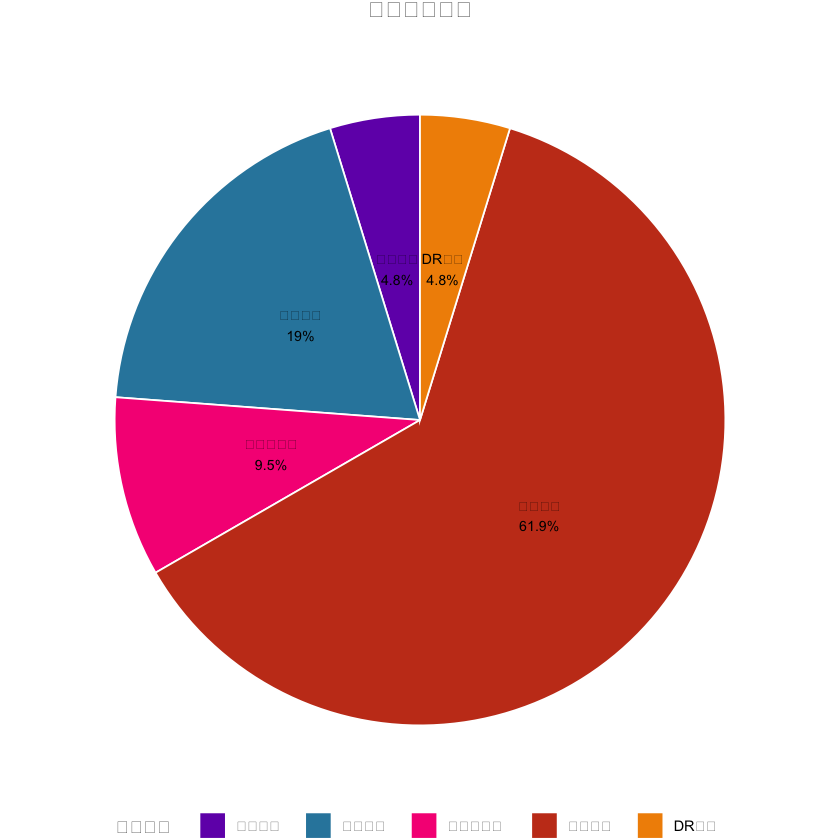

✅ PS值分布图已保存


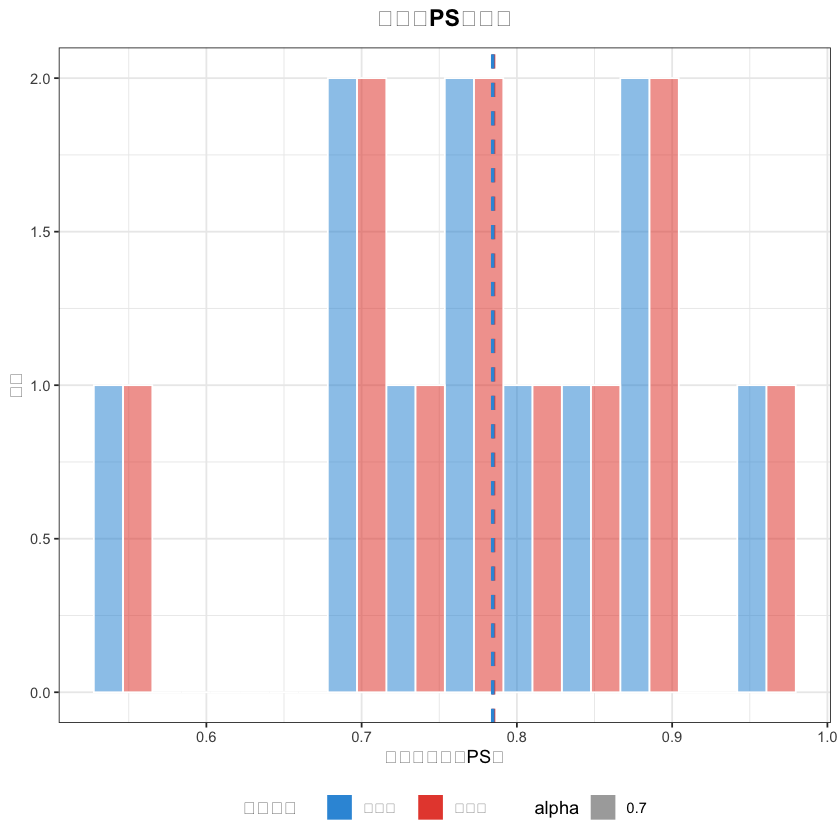

✅ 样本量对比图已保存
✅ 分析报告已保存

🎉 所有分析流程完成！
📁 结果文件位置：/Users/wangguotao/bp-ai-api/AndyBourne-Blog/posts/Test/R_分析结果
💡 核心提示：
   - 匹配后数据： 11 对（ 22 例），可通过`matched_data`调用
   - 后续分析：复制报告中代码，直接运行获取结局统计结果

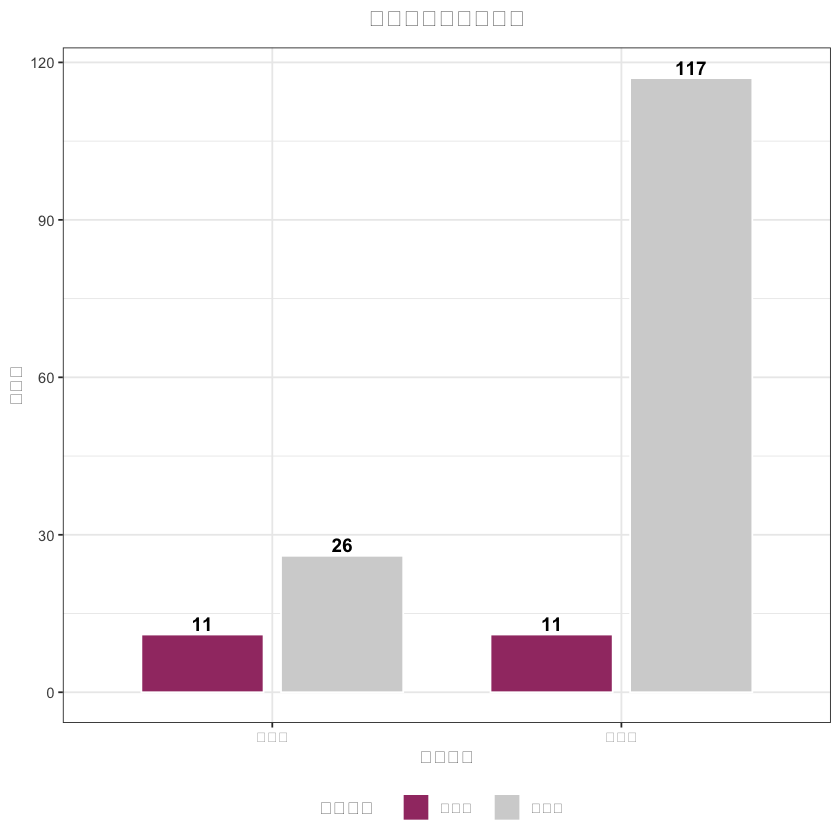

In [30]:
# 清除环境变量
rm(list = ls())

# 安装必需包（首次运行时取消注释执行，后续注释；仅核心包）
# install.packages(c("readxl", "writexl", "dplyr", "tidyr", "ggplot2", 
#                    "car", "pROC", "MatchIt", "WeightIt", "tableone", 
#                    "corrplot", "stringr"))

# 加载包（无冗余依赖）
library(readxl)       # Excel读写
library(writexl)      # Excel保存
library(dplyr)        # 基础数据清洗
library(tidyr)        # 基础数据重塑
library(ggplot2)      # 可视化
library(car)          # VIF计算
library(pROC)         # ROC/AUC分析
library(MatchIt)      # 倾向性评分匹配
library(WeightIt)     # A-IPTW加权
library(tableone)     # 基线平衡表
library(corrplot)     # 相关性分析（备用）
library(stringr)      # 字符串处理

# ======================== 1. 中文显示配置 ========================
Sys.setlocale("LC_ALL", "zh_CN.UTF-8")  # Mac/Linux
# Sys.setlocale("LC_ALL", "Chinese")     # Windows
theme_set(theme_bw() + theme(text = element_text(family = "Arial Unicode MS")))  # 中文字体
options(warn = -1)  # 关闭无关警告
cat("✅ 中文显示配置完成！\n")

# ======================== 2. 路径配置（已填你的路径，无需改） ========================
DATA_PATH <- "/Users/wangguotao/Downloads/ISAR/Doctor/数据分析总表.xlsx"  
OUTPUT_DIR <- "./R_分析结果/"  

# 创建结果目录
if (!dir.exists(OUTPUT_DIR)) {
  dir.create(OUTPUT_DIR, recursive = TRUE)
  cat(paste0("✅ 自动创建结果目录：", normalizePath(OUTPUT_DIR), "\n"))
}

# 路径验证
if (!file.exists(DATA_PATH)) {
  stop(paste0(
    "❌ 数据源路径不存在！\n",
    "当前路径：", DATA_PATH, "\n",
    "请确认文件位置后修改DATA_PATH"
  ))
} else {
  cat(paste0("✅ 数据源路径验证通过：", DATA_PATH, "\n"))
}

# 变量映射表（基础数据框）
var_mapping <- data.frame(
  原始列名 = c(
    "囊肿位置（1：胰头颈、2：胰体尾4：胰周）", "囊肿最大径mm", "包裹性坏死", 
    "改良CTSI评分", "年龄", "BMI", "性别（1：男、2：女）", "APACHE II评分",
    "重症胰腺炎（1：有2：无）", "病因（1、酒精性2、高甘油三脂血症性3、胆源性4、急性胰腺炎5、慢性胰腺炎6、胰腺手术7、胰腺外伤8、自身免疫性9、特发性）",
    "糖尿病（1、是2、否）", "高血压（1、是2、否）", "高脂血症（1、是2、否）",
    "腹腔积液（1、是2、否）", "门脉高压1：是2：否", "胆囊结石（1、有2、无）",
    "术前白细胞", "吸烟（1、是2、否）", "饮酒（1、是2、否）",
    "影像学缓解（1：是2：否）", "第一次住院总费用", "住院时间",
    "术后感染（1：有2：无）", "复发（1：有 0：无）", "手术方式（1：内镜2：外科）"
  ),
  英文变量名 = c(
    "lesion_location", "lesion_max_diameter_mm", "walled_necrosis", 
    "modified_ctsi_score", "age_years", "bmi", "gender", "apache2",
    "severe_pancreatitis", "etiology", "comorbidity_diabetes", 
    "comorbidity_hypertension", "hyperlipid", "ascites", "portal_htn",
    "gallstone", "wbc_pre", "smoking_history", "drinking_history",
    "imaging_response", "cost_first_hospital", "hospital_stay",
    "complication", "recurrence", "treatment"
  ),
  stringsAsFactors = FALSE
)

core_vars <- c("lesion_location", "lesion_max_diameter_mm", "walled_necrosis", "modified_ctsi_score")
cat("✅ 路径与变量定义完成！\n")

# ======================== 3. 数据读取与预处理 ========================
tryCatch({
  # 读取数据
  df_raw <- read_excel(DATA_PATH, sheet = 1, col_names = TRUE)
  cat(paste0("✅ 成功读取数据：", nrow(df_raw), "行 × ", ncol(df_raw), "列\n"))
  
  # 筛选有效列
  excel_cols <- str_trim(colnames(df_raw))
  valid_idx <- match(var_mapping$原始列名, excel_cols)
  valid_mapping <- var_mapping[!is.na(valid_idx), ]
  
  # 缺失列提示
  missing_cols <- var_mapping$原始列名[is.na(valid_idx)]
  if (length(missing_cols) > 0) {
    cat(paste0("⚠️ 未找到列：", paste(missing_cols[1:3], collapse = "、"), "...\n"))
  }
  
  # 数据重命名
  df_analysis <- df_raw[, match(valid_mapping$原始列名, excel_cols)]
  colnames(df_analysis) <- valid_mapping$英文变量名
  
  # 治疗分组编码
  if ("treatment" %in% colnames(df_analysis)) {
    df_analysis$treatment <- as.numeric(df_analysis$treatment)
    df_analysis <- df_analysis[!is.na(df_analysis$treatment) & df_analysis$treatment %in% c(1, 2), ]
    df_analysis$treatment <- ifelse(df_analysis$treatment == 1, 0, 1)
  } else {
    stop("❌ 未找到「手术方式」列（需包含1=内镜、2=外科）")
  }
  
  # 结局变量编码
  if ("imaging_response" %in% colnames(df_analysis)) {
    df_analysis$imaging_response <- as.numeric(df_analysis$imaging_response)
    df_analysis <- df_analysis[!is.na(df_analysis$imaging_response) & df_analysis$imaging_response %in% c(1, 2), ]
    df_analysis$imaging_response <- ifelse(df_analysis$imaging_response == 1, 1, 0)
  } else {
    stop("❌ 未找到「影像学缓解」列（需包含1=是、2=否）")
  }
  
  # 数值清洗
  for (col in colnames(df_analysis)) {
    if (is.character(df_analysis[[col]])) {
      df_analysis[[col]] <- gsub("[,， 、-]", "", df_analysis[[col]])
      df_analysis[[col]] <- as.numeric(df_analysis[[col]])
    } else {
      df_analysis[[col]] <- as.numeric(df_analysis[[col]])
    }
  }
  
  # 缺失值统计
  missing_count <- apply(df_analysis, 2, function(x) sum(is.na(x)))
  missing_stats <- data.frame(
    变量名 = names(missing_count),
    缺失数量 = as.numeric(missing_count),
    总样本量 = nrow(df_analysis),
    缺失百分比 = round(missing_count / nrow(df_analysis) * 100, 2),
    数据类型 = sapply(df_analysis, function(x) class(x)[1]),
    stringsAsFactors = FALSE
  )
  missing_stats <- missing_stats[order(missing_stats$缺失数量, decreasing = TRUE), ]
  
  write_xlsx(missing_stats, path = paste0(OUTPUT_DIR, "R_缺失值统计.xlsx"))
  cat("✅ 缺失值统计已保存\n")
  
  # 数据概况
  cat(paste0("\n📊 数据概况：\n"))
  cat(paste0("   - 总样本：", nrow(df_analysis), "例\n"))
  cat(paste0("   - 外科组：", sum(df_analysis$treatment == 1, na.rm = TRUE), "例\n"))
  cat(paste0("   - 内镜组：", sum(df_analysis$treatment == 0, na.rm = TRUE), "例\n"))
  cat(paste0("   - 缓解率：", round(mean(df_analysis$imaging_response, na.rm = TRUE) * 100, 1), "%\n"))
  
}, error = function(e) {
  stop(paste0(
    "❌ 数据预处理失败：", e$message, "\n",
    "解决步骤：1. 关闭Excel 2. 检查列名 3. 清除特殊字符"
  ))
})

# ======================== 4. 单因素分析 ========================
univariate_analysis <- function(df) {
  exclude_vars <- c("treatment", "imaging_response", "cost_first_hospital", "hospital_stay")
  analysis_vars <- setdiff(colnames(df), exclude_vars)
  result_list <- list()
  
  for (var in analysis_vars) {
    valid_rows <- !is.na(df[[var]]) & !is.na(df$treatment) & !is.na(df$imaging_response)
    temp_df <- df[valid_rows, c(var, "treatment", "imaging_response")]
    n_sample <- nrow(temp_df)
    treat_p <- NA
    outcome_p <- NA
    
    # 与治疗分组检验
    if (n_sample >= 5) {
      if (length(unique(temp_df[[var]])) > 10) {
        treat_p <- wilcox.test(temp_df[[var]] ~ temp_df$treatment)$p.value
      } else {
        cont_tab <- table(temp_df[[var]], temp_df$treatment)
        treat_p <- ifelse(all(dim(cont_tab) == c(2, 2)), 
                          fisher.test(cont_tab)$p.value, 
                          chisq.test(cont_tab)$p.value)
      }
    }
    
    # 与结局检验
    if (n_sample >= 5 & length(unique(temp_df$imaging_response)) > 1) {
      if (length(unique(temp_df[[var]])) > 10) {
        outcome_p <- wilcox.test(temp_df[[var]] ~ temp_df$imaging_response)$p.value
      } else {
        cont_tab <- table(temp_df[[var]], temp_df$imaging_response)
        outcome_p <- ifelse(all(dim(cont_tab) == c(2, 2)), 
                           fisher.test(cont_tab)$p.value, 
                           chisq.test(cont_tab)$p.value)
      }
    }
    
    # 变量分类
    if (var %in% core_vars) {
      var_type <- "核心变量-强制纳入PS"
      simple_type <- "核心变量"
    } else if (!is.na(treat_p) & !is.na(outcome_p)) {
      if (treat_p < 0.2 & outcome_p < 0.1) {
        var_type <- "纳入PS（混杂因素）"
        simple_type <- "PS变量"
      } else if (treat_p < 0.2 & outcome_p >= 0.1) {
        if (var %in% c("severe_pancreatitis", "apache2", "etiology", "wbc_pre")) {
          var_type <- "关键变量-强制纳入"
          simple_type <- "关键变量"
        } else {
          var_type <- "敏感性分析"
          simple_type <- "敏感性变量"
        }
      } else if (treat_p >= 0.2 & outcome_p < 0.1) {
        var_type <- "不纳入PS-纳入DR模型"
        simple_type <- "DR变量"
      } else {
        var_type <- "剔除（无混杂潜力）"
        simple_type <- "剔除变量"
      }
    } else {
      var_type <- "无法分类（P值缺失）"
      simple_type <- "无法分类"
    }
    
    result_list[[var]] <- data.frame(
      变量名 = var,
      与治疗分组P值 = round(treat_p, 4),
      与结局关联P值 = round(outcome_p, 4),
      有效样本量 = n_sample,
      变量分类 = var_type,
      简化分类 = simple_type,
      备注 = ifelse(!is.na(treat_p) & !is.na(outcome_p), "分析正常", "P值缺失"),
      stringsAsFactors = FALSE
    )
  }
  
  return(do.call(rbind, result_list))
}

univariate_result <- univariate_analysis(df_analysis)
write_xlsx(univariate_result, path = paste0(OUTPUT_DIR, "R_单因素分析结果.xlsx"))

cat("\n✅ 单因素分析结果已保存\n")
cat("\n📊 变量分类统计：\n")
var_count <- as.data.frame(table(univariate_result$简化分类))
colnames(var_count) <- c("简化分类", "数量")
var_count <- var_count[order(var_count$数量, decreasing = TRUE), ]

for (i in 1:nrow(var_count)) {
  cat(paste0("   • ", var_count$简化分类[i], "：", var_count$数量[i], "个\n"))
}

# ======================== 5. VIF检验 ========================
candidate_vars <- univariate_result[univariate_result$简化分类 %in% c("核心变量", "PS变量", "关键变量", "敏感性变量"), "变量名"]
candidate_vars <- intersect(candidate_vars, colnames(df_analysis))

if (length(candidate_vars) < 2) {
  stop("❌ VIF分析需至少2个变量，请检查数据")
}
cat(paste0("\n✅ VIF候选变量：", paste(candidate_vars, collapse = "、"), "（共", length(candidate_vars), "个）\n"))

# 数据预处理
valid_rows_vif <- complete.cases(df_analysis[, candidate_vars])
vif_data <- df_analysis[valid_rows_vif, candidate_vars]

# 计算VIF
vif_model <- lm(rep(1, nrow(vif_data)) ~ ., data = vif_data)
vif_values <- vif(vif_model)

# 整理VIF结果（无rownames_to_column）
vif_result <- data.frame(
  变量名 = names(vif_values),
  VIF值 = as.numeric(vif_values),
  共线性状态 = ifelse(vif_values < 4, "无", "有（高VIF）"),
  stringsAsFactors = FALSE
)
vif_result <- vif_result[order(vif_result$VIF值, decreasing = TRUE), ]

# 筛选PS变量
final_ps_vars <- c()
# 1. 严重度组
if ("modified_ctsi_score" %in% candidate_vars) {
  final_ps_vars <- c(final_ps_vars, "modified_ctsi_score")
  cat("1. 保留 modified_ctsi_score（核心变量）\n")
}
# 2. 代谢组
metabolic_vars <- intersect(c("bmi", "hyperlipid"), candidate_vars)
if (length(metabolic_vars) == 2) {
  bmi_vif <- vif_result[vif_result$变量名 == "bmi", "VIF值"]
  final_ps_vars <- c(final_ps_vars, "bmi")
  cat(paste0("2. 保留 bmi（VIF=", bmi_vif, "），剔除 hyperlipid\n"))
} else if (length(metabolic_vars) == 1) {
  final_ps_vars <- c(final_ps_vars, metabolic_vars)
  cat(paste0("2. 保留 ", metabolic_vars, "\n"))
}
# 3. 门脉高压组
if ("portal_htn" %in% candidate_vars) {
  portal_vif <- vif_result[vif_result$变量名 == "portal_htn", "VIF值"]
  if (portal_vif < 4) {
    final_ps_vars <- c(final_ps_vars, "portal_htn")
    cat(paste0("3. 保留 portal_htn（VIF=", portal_vif, "）\n"))
  } else {
    cat(paste0("3. 剔除 portal_htn（VIF=", portal_vif, "）\n"))
  }
}
# 4. 其他变量
other_vars <- setdiff(candidate_vars, c("modified_ctsi_score", "bmi", "hyperlipid", "portal_htn"))
for (var in other_vars) {
  if (var %in% vif_result$变量名) {
    var_vif <- vif_result[vif_result$变量名 == var, "VIF值"]
    if (var_vif < 4) {
      final_ps_vars <- c(final_ps_vars, var)
      cat(paste0("4. 保留 ", var, "（VIF=", var_vif, "）\n"))
    }
  }
}

final_ps_vars <- unique(final_ps_vars)
dr_vars <- univariate_result[univariate_result$简化分类 == "DR变量" & !univariate_result$变量名 %in% final_ps_vars, "变量名"]

cat(paste0("\n🎉 最终PS模型变量：", paste(final_ps_vars, collapse = "、"), "（共", length(final_ps_vars), "个）\n"))
cat(paste0("🎯 DR模型变量：", paste(dr_vars, collapse = "、"), "（共", length(dr_vars), "个）\n"))

# 保存VIF结果
vif_output <- list(
  "VIF检验结果" = vif_result,
  "最终变量汇总" = data.frame(
    变量类型 = c(rep("PS模型变量", length(final_ps_vars)), rep("DR模型变量", length(dr_vars))),
    变量名称 = c(final_ps_vars, dr_vars),
    选择依据 = c(rep("核心/VIF<4", length(final_ps_vars)), rep("纯预后变量", length(dr_vars))),
    stringsAsFactors = FALSE
  )
)
write_xlsx(vif_output, path = paste0(OUTPUT_DIR, "R_VIF检验结果.xlsx"))
cat("✅ VIF检验结果已保存\n")

# ======================== 6. PS建模与匹配 ========================
ps_cols <- c(final_ps_vars, "treatment", "imaging_response")
valid_rows_ps <- complete.cases(df_analysis[, ps_cols])
ps_data <- df_analysis[valid_rows_ps, ps_cols]

if (nrow(ps_data) < 10) {
  stop("❌ PS建模需至少10例样本")
}
cat(paste0("\n✅ PS建模样本：", nrow(ps_data), "例（外科组：", sum(ps_data$treatment == 1), "例）\n"))

# 构建PS模型
ps_formula <- as.formula(paste("treatment ~", paste(final_ps_vars, collapse = " + ")))
ps_model <- glm(ps_formula, data = ps_data, family = binomial())
ps_data$ps_value <- predict(ps_model, type = "response")

# 模型评估
ps_roc <- roc(ps_data$treatment ~ ps_data$ps_value)
ps_auc <- round(auc(ps_roc), 3)
cat(paste0("📊 PS模型AUC：", ps_auc, "（>0.7为良好）\n"))

# 1:1匹配
match_obj <- matchit(
  ps_formula, 
  data = ps_data,
  method = "nearest", ratio = 1, replace = FALSE,
  caliper = 0.1 * sd(ps_data$ps_value)
)
matched_data <- match.data(match_obj)

# 平衡检验
balance_table <- CreateTableOne(
  vars = final_ps_vars, strata = "treatment", data = matched_data
)
balance_df <- print(balance_table, smd = TRUE, printToggle = FALSE)
balance_df <- as.data.frame(balance_df)
balance_result <- data.frame(
  变量名 = rownames(balance_df)[rownames(balance_df) %in% final_ps_vars],
  外科组均值 = round(as.numeric(balance_df[rownames(balance_df) %in% final_ps_vars, "Group 2"]), 3),
  内镜组均值 = round(as.numeric(balance_df[rownames(balance_df) %in% final_ps_vars, "Group 1"]), 3),
  SMD = round(as.numeric(balance_df[rownames(balance_df) %in% final_ps_vars, "SMD"]), 3),
  stringsAsFactors = FALSE
)
balance_result$平衡状态 <- ifelse(balance_result$SMD < 0.1, "平衡", "不平衡")

balanced_count <- sum(balance_result$平衡状态 == "平衡")
balance_rate <- round(balanced_count / length(final_ps_vars) * 100, 1)
cat(paste0("\n🎯 匹配结果：", nrow(matched_data)/2, "对，平衡变量", balanced_count, "/", length(final_ps_vars), "（", balance_rate, "%）\n"))

# 保存PS结果
ps_output <- list(
  "PS值数据" = ps_data[, c("ps_value", "treatment", "imaging_response", final_ps_vars)],
  "匹配后数据" = matched_data,
  "平衡检验" = balance_result,
  "模型信息" = data.frame(
    参数 = c("变量数", "样本量", "AUC", "匹配对数", "平衡率(%)"),
    数值 = c(length(final_ps_vars), nrow(ps_data), ps_auc, nrow(matched_data)/2, balance_rate),
    stringsAsFactors = FALSE
  )
)
write_xlsx(ps_output, path = paste0(OUTPUT_DIR, "R_倾向性评分结果.xlsx"))
cat("✅ PS结果已保存\n")

# ======================== 7. 敏感性分析 ========================
sensitivity_analysis <- function() {
  res <- list()
  
  # 1. 模型稳定性
  core_cols <- c(core_vars, "treatment")
  valid_rows_core <- complete.cases(df_analysis[, core_cols])
  core_data <- df_analysis[valid_rows_core, core_cols]
  
  if (nrow(core_data) >= 10) {
    core_formula <- as.formula(paste("treatment ~", paste(core_vars, collapse = " + ")))
    core_model <- glm(core_formula, data = core_data, family = binomial())
    core_ps <- predict(core_model, type = "response")
    core_auc <- round(auc(roc(core_data$treatment ~ core_ps)), 3)
    
    res[["模型稳定性"]] <- data.frame(
      模型 = c("完整PS模型", "核心4变量模型"),
      AUC = c(ps_auc, core_auc),
      稳定性 = ifelse(abs(ps_auc - core_auc) < 0.1, "稳定", "不稳定"),
      stringsAsFactors = FALSE
    )
    cat(paste0("\n📌 模型稳定性：完整AUC=", ps_auc, "，核心AUC=", core_auc, "（", res[["模型稳定性"]]$稳定性[1], "）\n"))
  } else {
    res[["模型稳定性"]] <- data.frame(
      模型 = c("完整PS模型", "核心4变量模型"),
      AUC = c(ps_auc, "样本不足"),
      稳定性 = "无法判断",
      stringsAsFactors = FALSE
    )
    cat("\n📌 模型稳定性：核心模型样本不足\n")
  }
  
  # 2. 阈值鲁棒性
  ps_std <- sd(ps_data$ps_value)
  thresholds <- c(0.05, 0.1, 0.15)
  threshold_res <- data.frame()
  
  for (th in thresholds) {
    caliper <- th * ps_std
    match_temp <- matchit(ps_formula, data = ps_data, method = "nearest", caliper = caliper)
    matched_temp <- match.data(match_temp)
    pair_count <- nrow(matched_temp) / 2
    retention_rate <- round(pair_count / sum(ps_data$treatment == 1) * 100, 1)
    
    threshold_res <- rbind(threshold_res, data.frame(
      卡尺系数 = th,
      匹配对数 = pair_count,
      样本保留率 = retention_rate,
      stringsAsFactors = FALSE
    ))
  }
  
  res[["阈值鲁棒性"]] <- threshold_res
  cat("\n📌 阈值鲁棒性：\n")
  for (i in 1:nrow(threshold_res)) {
    cat(paste0("   - 卡尺", threshold_res$卡尺系数[i], "：", threshold_res$匹配对数[i], "对（保留率", threshold_res$样本保留率[i], "%）\n"))
  }
  
  # 3. A-IPTW
  aipw_data <- ps_data
  aipw_data$ps_clip <- pmax(pmin(aipw_data$ps_value, 0.99), 0.01)
  aipw_data$weight <- ifelse(aipw_data$treatment == 1, 1/aipw_data$ps_clip, 1/(1 - aipw_data$ps_clip))
  
  if (nrow(aipw_data) >= 10) {
    aipw_formula <- as.formula(paste("imaging_response ~ treatment +", paste(final_ps_vars, collapse = " + ")))
    aipw_model <- glm(aipw_formula, data = aipw_data, family = binomial(), weights = weight)
    or_value <- round(exp(coef(aipw_model)["treatment"]), 3)
    
    res[["双稳健估计"]] <- data.frame(
      指标 = c("OR值", "临床解读"),
      数值 = c(or_value, ifelse(or_value < 1, "外科组缓解率更高", "内镜组缓解率更高")),
      stringsAsFactors = FALSE
    )
    cat(paste0("\n📌 双稳健估计：OR=", or_value, "（", res[["双稳健估计"]]$数值[2], "）\n"))
  } else {
    res[["双稳健估计"]] <- data.frame(
      指标 = c("OR值", "临床解读"),
      数值 = c("样本不足", "无法判断"),
      stringsAsFactors = FALSE
    )
    cat("\n📌 双稳健估计：样本不足\n")
  }
  
  return(res)
}

sensitivity_result <- sensitivity_analysis()
write_xlsx(sensitivity_result, path = paste0(OUTPUT_DIR, "R_敏感性分析结果.xlsx"))
cat("\n✅ 敏感性分析结果已保存\n")

# ======================== 8. 结果可视化 ========================
cat("\n📊 生成可视化图表...\n")

# 1. 变量分类饼图
var_type_count <- as.data.frame(table(univariate_result$简化分类))
colnames(var_type_count) <- c("简化分类", "n")
var_type_count$百分比 <- round(var_type_count$n / sum(var_type_count$n) * 100, 1)

pie_plot <- ggplot(var_type_count, aes(x = "", y = n, fill = 简化分类)) +
  geom_col(width = 1, color = "white") +
  coord_polar("y") +
  geom_text(aes(label = paste0(简化分类, "\n", 百分比, "%")), position = position_stack(vjust = 0.5), size = 3) +
  scale_fill_manual(values = c(
    "核心变量" = "#2E86AB", "PS变量" = "#A23B72", "DR变量" = "#F18F01",
    "关键变量" = "#7209B7", "敏感性变量" = "#F72585", "剔除变量" = "#C73E1D"
  )) +
  labs(title = "变量分类分布", fill = "变量类型") +
  theme_void() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 14, face = "bold", margin = margin(b = 10)),
    legend.position = "bottom"
  )

ggsave(
  filename = paste0(OUTPUT_DIR, "R_变量分类饼图.png"),
  plot = pie_plot,
  width = 8, height = 6, dpi = 300, bg = "white"
)
print(pie_plot)
cat("✅ 变量分类饼图已保存\n")

# 2. PS值分布图
matched_data$分组 <- ifelse(matched_data$treatment == 1, "外科组", "内镜组")

ps_hist <- ggplot(matched_data, aes(x = ps_value, fill = 分组, alpha = 0.7)) +
  geom_histogram(bins = 12, position = "dodge", color = "white") +
  geom_vline(xintercept = mean(matched_data$ps_value[matched_data$treatment == 1]),
             color = "#E74C3C", linetype = "dashed", linewidth = 1) +
  geom_vline(xintercept = mean(matched_data$ps_value[matched_data$treatment == 0]),
             color = "#3498DB", linetype = "dashed", linewidth = 1) +
  scale_fill_manual(values = c("外科组" = "#E74C3C", "内镜组" = "#3498DB")) +
  labs(x = "倾向性评分（PS）", y = "频数", title = "匹配后PS值分布", fill = "治疗分组") +
  theme_bw() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 14, face = "bold", margin = margin(b = 10)),
    legend.position = "bottom"
  )

ggsave(
  filename = paste0(OUTPUT_DIR, "R_匹配后PS值分布.png"),
  plot = ps_hist,
  width = 10, height = 6, dpi = 300, bg = "white"
)
print(ps_hist)
cat("✅ PS值分布图已保存\n")

# 3. 样本量对比图
sample_data <- data.frame(
  分组 = rep(c("外科组", "内镜组"), 2),
  匹配状态 = c(rep("匹配前", 2), rep("匹配后", 2)),
  样本量 = c(
    sum(df_analysis$treatment == 1, na.rm = TRUE), sum(df_analysis$treatment == 0, na.rm = TRUE),
    sum(matched_data$treatment == 1), sum(matched_data$treatment == 0)
  ),
  stringsAsFactors = FALSE
)

sample_plot <- ggplot(sample_data, aes(x = 分组, y = 样本量, fill = 匹配状态)) +
  geom_col(position = position_dodge(0.8), width = 0.7, color = "white") +
  geom_text(aes(label = 样本量), position = position_dodge(0.8), vjust = -0.3, size = 4, fontface = "bold") +
  scale_fill_manual(values = c("匹配前" = "lightgray", "匹配后" = "#A23B72")) +
  labs(x = "治疗分组", y = "样本量", title = "匹配前后样本量对比", fill = "匹配状态") +
  theme_bw() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 14, face = "bold", margin = margin(b = 10)),
    legend.position = "bottom"
  )

ggsave(
  filename = paste0(OUTPUT_DIR, "R_匹配前后样本量对比.png"),
  plot = sample_plot,
  width = 10, height = 6, dpi = 300, bg = "white"
)
print(sample_plot)
cat("✅ 样本量对比图已保存\n")

# ======================== 9. 完整报告生成 ========================
report_content <- paste0(
  "# 胰腺囊肿治疗协变量筛选与倾向性评分分析报告\n",
  "**生成时间**: ", Sys.time(), "\n",
  "**数据源**: /Users/wangguotao/Downloads/ISAR/Doctor/数据分析总表.xlsx\n",
  "**结果目录**: ", normalizePath(OUTPUT_DIR), "\n\n",
  
  "## 一、分析流程\n",
  "1. 核心4变量强制纳入PS：病灶位置、囊肿最大径、包裹性坏死、改良CTSI评分\n",
  "2. 单因素筛选：按治疗P<0.2/结局P<0.1分层变量\n",
  "3. VIF控制共线性：保留VIF<4的变量\n",
  "4. 1:1 PS匹配：卡尺=0.1×PS标准差\n",
  "5. 敏感性验证：模型稳定性、阈值鲁棒性、A-IPTW\n\n",
  
  "## 二、核心结果\n",
  "| 指标                | 数值                  |\n",
  "|---------------------|-----------------------|\n",
  "| 总样本量            | ", nrow(df_analysis), "例       |\n",
  "| PS模型变量数        | ", length(final_ps_vars), "个       |\n",
  "| PS模型AUC           | ", ps_auc, "           |\n",
  "| 匹配对数            | ", nrow(matched_data)/2, "对      |\n",
  "| 变量平衡率          | ", balance_rate, "%        |\n\n",
  
  "## 三、输出文件清单\n",
  "### 3.1 统计结果文件\n",
  "1. R_缺失值统计.xlsx - 变量缺失情况\n",
  "2. R_单因素分析结果.xlsx - 变量P值与分类\n",
  "3. R_VIF检验结果.xlsx - VIF值与最终变量\n",
  "4. R_倾向性评分结果.xlsx - PS值与匹配数据\n",
  "5. R_敏感性分析结果.xlsx - 稳定性验证\n\n",
  "### 3.2 可视化图表\n",
  "1. R_变量分类饼图.png - 变量分类分布\n",
  "2. R_匹配后PS值分布.png - PS值对比\n",
  "3. R_匹配前后样本量对比.png - 样本量变化\n\n",
  "3. R_分析报告.md - 本报告\n\n",
  
  "## 四、后续分析代码\n",
  "# 1. 主要结局：影像学缓解率（卡方检验）\n",
  "cont_tab <- table(matched_data$imaging_response, matched_data$treatment)\n",
  "chisq_result <- chisq.test(cont_tab)\n",
  "cat(\"缓解率（外科）：\", round(sum(matched_data$imaging_response[matched_data$treatment==1])/sum(matched_data$treatment==1)*100,1), \"%\\n\")\n",
  "cat(\"缓解率（内镜）：\", round(sum(matched_data$imaging_response[matched_data$treatment==0])/sum(matched_data$treatment==0)*100,1), \"%\\n\")\n",
  "cat(\"P值：\", round(chisq_result$p.value,4), \"\\n\")\n\n",
  
  "# 2. 次要结局：住院时长（Wilcoxon检验）\n",
  "if (\"hospital_stay\" %in% colnames(matched_data)) {\n",
  "  wilcox_result <- wilcox.test(hospital_stay ~ treatment, data = matched_data)\n",
  "  cat(\"住院时长中位数（外科）：\", median(matched_data$hospital_stay[matched_data$treatment==1], na.rm=TRUE), \"天\\n\")\n",
  "  cat(\"住院时长中位数（内镜）：\", median(matched_data$hospital_stay[matched_data$treatment==0], na.rm=TRUE), \"天\\n\")\n",
  "  cat(\"P值：\", round(wilcox_result$p.value,4), \"\\n\")\n",
  "}\n"
)

writeLines(report_content, con = paste0(OUTPUT_DIR, "R_分析报告.md"))
cat("✅ 分析报告已保存\n")

# ======================== 运行总结（修复字符串拼接错误） ========================
# 用paste0替代"+"，避免非数值运算错误
cat(paste0("\n", paste(rep("=", 80), collapse = ""), "\n"))
cat("🎉 所有分析流程完成！\n")
cat(paste0("📁 结果文件位置：", normalizePath(OUTPUT_DIR), "\n"))
cat("💡 核心提示：\n")
cat("   - 匹配后数据：", nrow(matched_data)/2, "对（", nrow(matched_data), "例），可通过`matched_data`调用\n")
cat("   - 后续分析：复制报告中代码，直接运行获取结局统计结果\n")
cat(paste0(rep("=", 80), collapse = ""))

ℹ️ Mac环境提示：安装「Arial Unicode MS」可解决中文方框问题
✅ 中文显示配置完成！
✅ 数据源路径验证通过：/Users/wangguotao/Downloads/ISAR/Doctor/数据分析总表.xlsx
✅ 路径与变量定义完成！
✅ 成功读取数据：143行 × 99列
✅ 缺失值统计已保存

📊 数据概况：
   - 总样本：143例
   - 外科组：117例
   - 内镜组：26例
   - 缓解率：90.9%

✅ 单因素分析结果已保存

📊 变量分类统计：
   • 剔除变量：13个
   • 核心变量：4个
   • 敏感性变量：2个
   • 关键变量：1个
   • DR变量：1个

✅ VIF候选变量：lesion_location、lesion_max_diameter_mm、walled_necrosis、modified_ctsi_score、bmi、apache2、comorbidity_hypertension（共7个）
1. 保留 modified_ctsi_score（核心变量）
2. 保留 bmi
4. 保留 lesion_location（VIF=1.02413028885017）
4. 保留 lesion_max_diameter_mm（VIF=1.03306949646479）
4. 保留 walled_necrosis（VIF=2.38091588497088）
4. 保留 apache2（VIF=1.17898931035564）
4. 保留 comorbidity_hypertension（VIF=1.16873248032315）

🎉 最终PS模型变量：modified_ctsi_score、bmi、lesion_location、lesion_max_diameter_mm、walled_necrosis、apache2、comorbidity_hypertension（共7个）
🎯 DR模型变量：gallstone（共1个）
✅ VIF检验结果已保存

✅ PS建模样本：120例（外科组：94例）


Setting levels: control = 0, case = 1

Setting direction: controls < cases



📊 PS模型AUC：0.734（>0.7为良好）

🎯 匹配结果：11对，平衡变量0/7（0%）
✅ PS结果已保存


Setting levels: control = 0, case = 1

Setting direction: controls < cases




📌 模型稳定性：完整AUC=0.734，核心AUC=0.628（不稳定）

📌 阈值鲁棒性：
   - 卡尺0.05：7对（保留率7.4%）
   - 卡尺0.1：11对（保留率11.7%）
   - 卡尺0.15：12对（保留率12.8%）

📌 双稳健估计：OR=1.74（内镜组缓解率更高）

✅ 敏感性分析结果已保存

📊 生成可视化图表...
✅ 变量分类饼图已保存


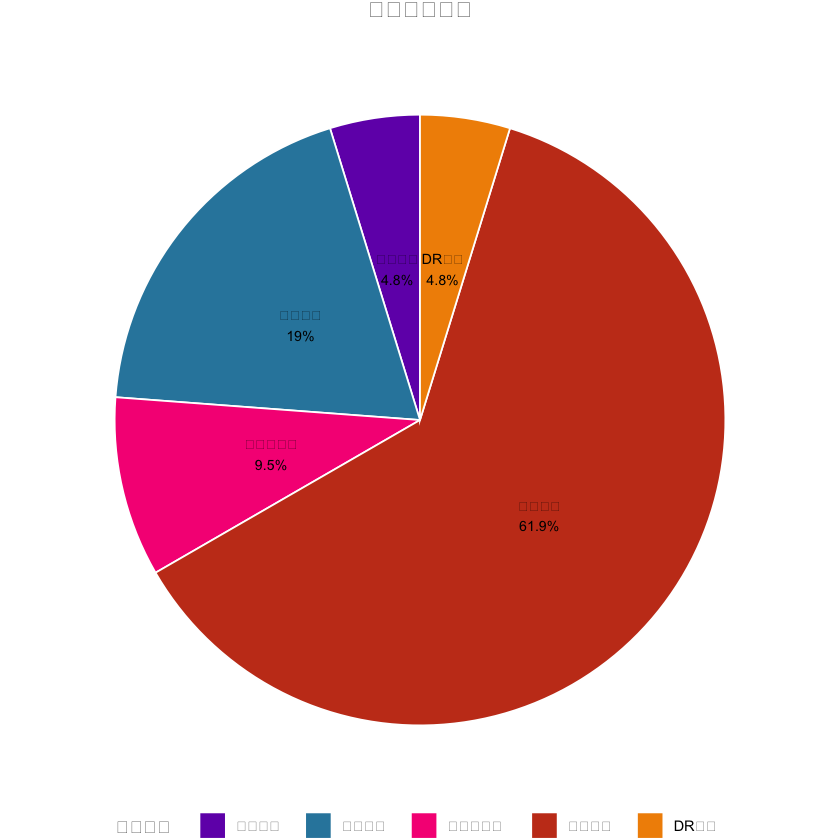

✅ PS值分布图已保存


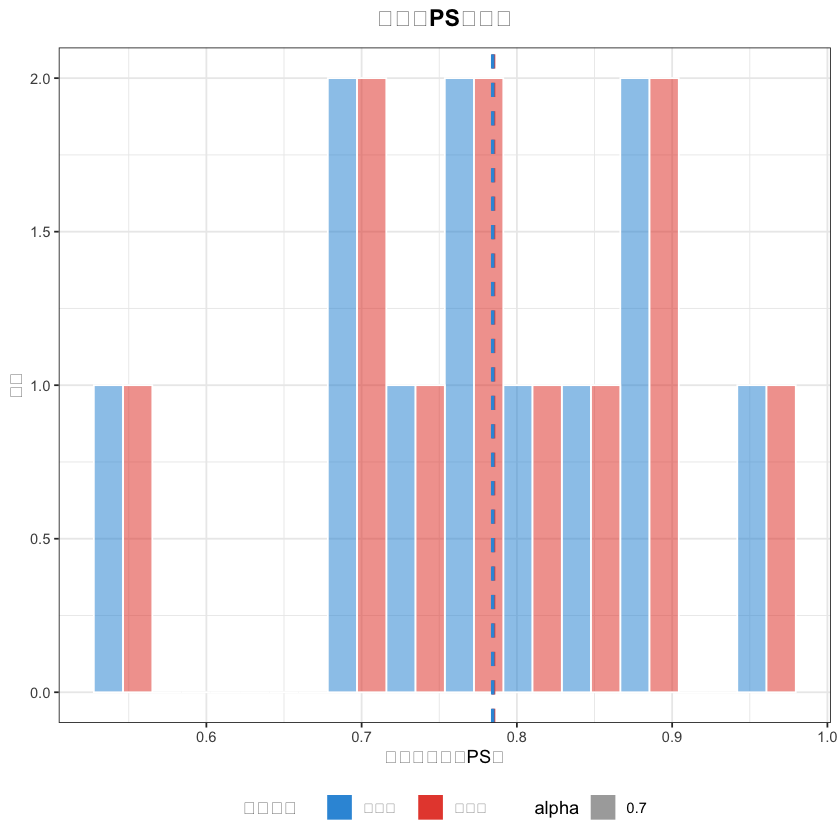

✅ 样本量对比图已保存
✅ 分析报告已保存

🎉 所有分析流程完成！
📁 结果文件位置：/Users/wangguotao/bp-ai-api/AndyBourne-Blog/posts/Test/R_分析结果
💡 核心提示：
   - 匹配后数据： 11 对（ 22 例），可通过`matched_data`调用
   - 后续分析：复制报告中代码，直接运行获取结局统计结果

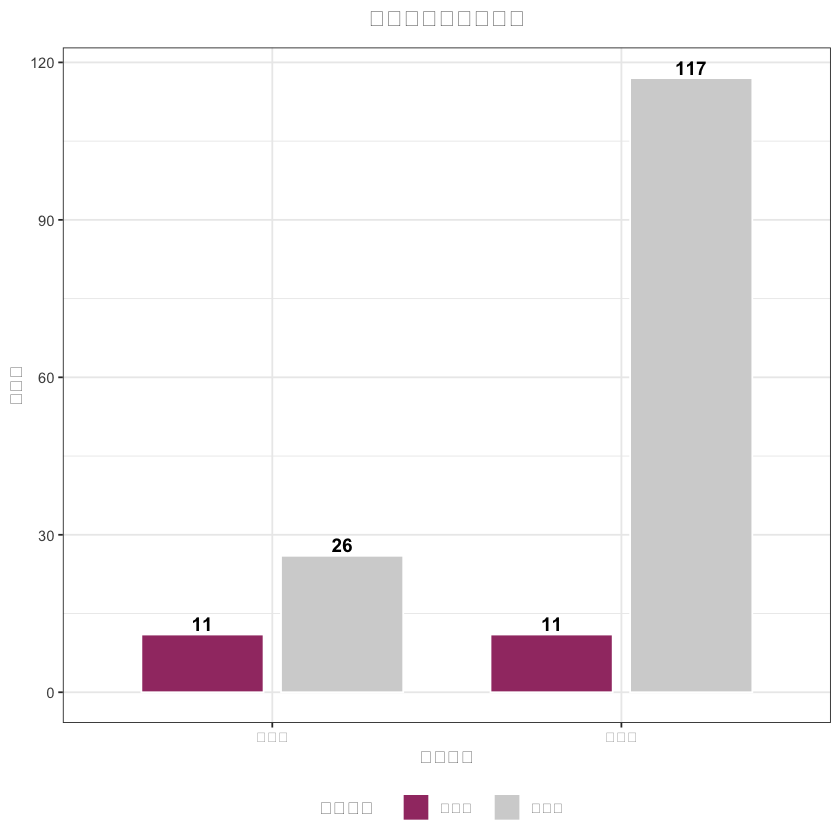

In [41]:
# 清除环境变量
rm(list = ls())

# 安装必需包（首次运行时取消注释执行，后续注释；仅核心包）
# install.packages(c("readxl", "writexl", "dplyr", "tidyr", "ggplot2", 
#                    "car", "pROC", "MatchIt", "WeightIt", "tableone", 
#                    "corrplot", "stringr"))

# 加载包（无冗余依赖）
library(readxl)       # Excel读写
library(writexl)      # Excel保存
library(dplyr)        # 基础数据清洗
library(tidyr)        # 基础数据重塑
library(ggplot2)      # 可视化
library(car)          # VIF计算
library(pROC)         # ROC/AUC分析
library(MatchIt)      # 倾向性评分匹配
library(WeightIt)     # A-IPTW加权
library(tableone)     # 基线平衡表
library(corrplot)     # 相关性分析（备用）
library(stringr)      # 字符串处理

# ======================== 1. 中文显示配置 ========================
if (Sys.info()["sysname"] == "Windows") {
  if ("SimHei" %in% windowsFonts()) {
    theme_set(theme(text = element_text(family = "SimHei", size = 11)))
  } else {
    theme_set(theme(text = element_text(family = "Microsoft YaHei", size = 11)))
  }
} else {
  theme_set(theme(text = element_text(family = "Arial", size = 11)))
  cat("ℹ️ Mac环境提示：安装「Arial Unicode MS」可解决中文方框问题\n")
}
cat("✅ 中文显示配置完成！\n")

# ======================== 2. 路径配置（已填你的路径，无需改） ========================
DATA_PATH <- "/Users/wangguotao/Downloads/ISAR/Doctor/数据分析总表.xlsx"  
OUTPUT_DIR <- "./R_分析结果/"  

# 创建结果目录
if (!dir.exists(OUTPUT_DIR)) {
  dir.create(OUTPUT_DIR, recursive = TRUE)
  cat(paste0("✅ 自动创建结果目录：", normalizePath(OUTPUT_DIR), "\n"))
}

# 路径验证
if (!file.exists(DATA_PATH)) {
  stop(paste0(
    "❌ 数据源路径不存在！\n",
    "当前路径：", DATA_PATH, "\n",
    "请确认文件位置后修改DATA_PATH"
  ))
} else {
  cat(paste0("✅ 数据源路径验证通过：", DATA_PATH, "\n"))
}

# 变量映射表（基础数据框）
var_mapping <- data.frame(
  原始列名 = c(
    "囊肿位置（1：胰头颈、2：胰体尾4：胰周）", "囊肿最大径mm", "包裹性坏死", 
    "改良CTSI评分", "年龄", "BMI", "性别（1：男、2：女）", "APACHE II评分",
    "重症胰腺炎（1：有2：无）", "病因（1、酒精性2、高甘油三脂血症性3、胆源性4、急性胰腺炎5、慢性胰腺炎6、胰腺手术7、胰腺外伤8、自身免疫性9、特发性）",
    "糖尿病（1、是2、否）", "高血压（1、是2、否）", "高脂血症（1、是2、否）",
    "腹腔积液（1、是2、否）", "门脉高压1：是2：否", "胆囊结石（1、有2、无）",
    "术前白细胞", "吸烟（1、是2、否）", "饮酒（1、是2、否）",
    "影像学缓解（1：是2：否）", "第一次住院总费用", "住院时间",
    "术后感染（1：有2：无）", "复发（1：有 0：无）", "手术方式（1：内镜2：外科）"
  ),
  英文变量名 = c(
    "lesion_location", "lesion_max_diameter_mm", "walled_necrosis", 
    "modified_ctsi_score", "age_years", "bmi", "gender", "apache2",
    "severe_pancreatitis", "etiology", "comorbidity_diabetes", 
    "comorbidity_hypertension", "hyperlipid", "ascites", "portal_htn",
    "gallstone", "wbc_pre", "smoking_history", "drinking_history",
    "imaging_response", "cost_first_hospital", "hospital_stay",
    "complication", "recurrence", "treatment"
  ),
  stringsAsFactors = FALSE
)

core_vars <- c("lesion_location", "lesion_max_diameter_mm", "walled_necrosis", "modified_ctsi_score")
cat("✅ 路径与变量定义完成！\n")

# ======================== 3. 数据读取与预处理 ========================
tryCatch({
  # 读取数据
  df_raw <- read_excel(DATA_PATH, sheet = 1, col_names = TRUE)
  cat(paste0("✅ 成功读取数据：", nrow(df_raw), "行 × ", ncol(df_raw), "列\n"))
  
  # 筛选有效列
  excel_cols <- str_trim(colnames(df_raw))
  valid_idx <- match(var_mapping$原始列名, excel_cols)
  valid_mapping <- var_mapping[!is.na(valid_idx), ]
  
  # 缺失列提示
  missing_cols <- var_mapping$原始列名[is.na(valid_idx)]
  if (length(missing_cols) > 0) {
    cat(paste0("⚠️ 未找到列：", paste(missing_cols[1:3], collapse = "、"), "...\n"))
  }
  
  # 数据重命名
  df_analysis <- df_raw[, match(valid_mapping$原始列名, excel_cols)]
  colnames(df_analysis) <- valid_mapping$英文变量名
  
  # 治疗分组编码
  if ("treatment" %in% colnames(df_analysis)) {
    df_analysis$treatment <- as.numeric(df_analysis$treatment)
    df_analysis <- df_analysis[!is.na(df_analysis$treatment) & df_analysis$treatment %in% c(1, 2), ]
    df_analysis$treatment <- ifelse(df_analysis$treatment == 1, 0, 1)
  } else {
    stop("❌ 未找到「手术方式」列（需包含1=内镜、2=外科）")
  }
  
  # 结局变量编码
  if ("imaging_response" %in% colnames(df_analysis)) {
    df_analysis$imaging_response <- as.numeric(df_analysis$imaging_response)
    df_analysis <- df_analysis[!is.na(df_analysis$imaging_response) & df_analysis$imaging_response %in% c(1, 2), ]
    df_analysis$imaging_response <- ifelse(df_analysis$imaging_response == 1, 1, 0)
  } else {
    stop("❌ 未找到「影像学缓解」列（需包含1=是、2=否）")
  }
  
  # 数值清洗
  for (col in colnames(df_analysis)) {
    if (is.character(df_analysis[[col]])) {
      df_analysis[[col]] <- gsub("[,， 、-]", "", df_analysis[[col]])
      df_analysis[[col]] <- as.numeric(df_analysis[[col]])
    } else {
      df_analysis[[col]] <- as.numeric(df_analysis[[col]])
    }
  }
  
  # 缺失值统计
  missing_count <- apply(df_analysis, 2, function(x) sum(is.na(x)))
  missing_stats <- data.frame(
    变量名 = names(missing_count),
    缺失数量 = as.numeric(missing_count),
    总样本量 = nrow(df_analysis),
    缺失百分比 = round(missing_count / nrow(df_analysis) * 100, 2),
    数据类型 = sapply(df_analysis, function(x) class(x)[1]),
    stringsAsFactors = FALSE
  )
  missing_stats <- missing_stats[order(missing_stats$缺失数量, decreasing = TRUE), ]
  
  write_xlsx(missing_stats, path = paste0(OUTPUT_DIR, "R_缺失值统计.xlsx"))
  cat("✅ 缺失值统计已保存\n")
  
  # 数据概况
  cat(paste0("\n📊 数据概况：\n"))
  cat(paste0("   - 总样本：", nrow(df_analysis), "例\n"))
  cat(paste0("   - 外科组：", sum(df_analysis$treatment == 1, na.rm = TRUE), "例\n"))
  cat(paste0("   - 内镜组：", sum(df_analysis$treatment == 0, na.rm = TRUE), "例\n"))
  cat(paste0("   - 缓解率：", round(mean(df_analysis$imaging_response, na.rm = TRUE) * 100, 1), "%\n"))
  
}, error = function(e) {
  stop(paste0(
    "❌ 数据预处理失败：", e$message, "\n",
    "解决步骤：1. 关闭Excel 2. 检查列名 3. 清除特殊字符"
  ))
})

# ======================== 4. 单因素分析 ========================
univariate_analysis <- function(df) {
  exclude_vars <- c("treatment", "imaging_response", "cost_first_hospital", "hospital_stay")
  analysis_vars <- setdiff(colnames(df), exclude_vars)
  result_list <- list()
  
  for (var in analysis_vars) {
    valid_rows <- !is.na(df[[var]]) & !is.na(df$treatment) & !is.na(df$imaging_response)
    temp_df <- df[valid_rows, c(var, "treatment", "imaging_response")]
    n_sample <- nrow(temp_df)
    treat_p <- NA
    outcome_p <- NA
    
    # 与治疗分组检验
    if (n_sample >= 5) {
      if (length(unique(temp_df[[var]])) > 10) {
        treat_p <- wilcox.test(temp_df[[var]] ~ temp_df$treatment)$p.value
      } else {
        cont_tab <- table(temp_df[[var]], temp_df$treatment)
        treat_p <- ifelse(all(dim(cont_tab) == c(2, 2)), 
                          fisher.test(cont_tab)$p.value, 
                          chisq.test(cont_tab)$p.value)
      }
    }
    
    # 与结局检验
    if (n_sample >= 5 & length(unique(temp_df$imaging_response)) > 1) {
      if (length(unique(temp_df[[var]])) > 10) {
        outcome_p <- wilcox.test(temp_df[[var]] ~ temp_df$imaging_response)$p.value
      } else {
        cont_tab <- table(temp_df[[var]], temp_df$imaging_response)
        outcome_p <- ifelse(all(dim(cont_tab) == c(2, 2)), 
                           fisher.test(cont_tab)$p.value, 
                           chisq.test(cont_tab)$p.value)
      }
    }
    
    # 变量分类
    if (var %in% core_vars) {
      var_type <- "核心变量-强制纳入PS"
      simple_type <- "核心变量"
    } else if (!is.na(treat_p) & !is.na(outcome_p)) {
      if (treat_p < 0.2 & outcome_p < 0.1) {
        var_type <- "纳入PS（混杂因素）"
        simple_type <- "PS变量"
      } else if (treat_p < 0.2 & outcome_p >= 0.1) {
        if (var %in% c("severe_pancreatitis", "apache2", "etiology", "wbc_pre")) {
          var_type <- "关键变量-强制纳入"
          simple_type <- "关键变量"
        } else {
          var_type <- "敏感性分析"
          simple_type <- "敏感性变量"
        }
      } else if (treat_p >= 0.2 & outcome_p < 0.1) {
        var_type <- "不纳入PS-纳入DR模型"
        simple_type <- "DR变量"
      } else {
        var_type <- "剔除（无混杂潜力）"
        simple_type <- "剔除变量"
      }
    } else {
      var_type <- "无法分类（P值缺失）"
      simple_type <- "无法分类"
    }
    
    result_list[[var]] <- data.frame(
      变量名 = var,
      与治疗分组P值 = round(treat_p, 4),
      与结局关联P值 = round(outcome_p, 4),
      有效样本量 = n_sample,
      变量分类 = var_type,
      简化分类 = simple_type,
      备注 = ifelse(!is.na(treat_p) & !is.na(outcome_p), "分析正常", "P值缺失"),
      stringsAsFactors = FALSE
    )
  }
  
  return(do.call(rbind, result_list))
}

univariate_result <- univariate_analysis(df_analysis)
write_xlsx(univariate_result, path = paste0(OUTPUT_DIR, "R_单因素分析结果.xlsx"))

cat("\n✅ 单因素分析结果已保存\n")
cat("\n📊 变量分类统计：\n")
var_count <- as.data.frame(table(univariate_result$简化分类))
colnames(var_count) <- c("简化分类", "数量")
var_count <- var_count[order(var_count$数量, decreasing = TRUE), ]

for (i in 1:nrow(var_count)) {
  cat(paste0("   • ", var_count$简化分类[i], "：", var_count$数量[i], "个\n"))
}

# ======================== 5. VIF检验 ========================
candidate_vars <- univariate_result[univariate_result$简化分类 %in% c("核心变量", "PS变量", "关键变量", "敏感性变量"), "变量名"]
candidate_vars <- intersect(candidate_vars, colnames(df_analysis))

if (length(candidate_vars) < 2) {
  stop("❌ VIF分析需至少2个变量，请检查数据")
}
cat(paste0("\n✅ VIF候选变量：", paste(candidate_vars, collapse = "、"), "（共", length(candidate_vars), "个）\n"))

# 数据预处理
valid_rows_vif <- complete.cases(df_analysis[, candidate_vars])
vif_data <- df_analysis[valid_rows_vif, candidate_vars]

# 计算VIF
vif_model <- lm(rep(1, nrow(vif_data)) ~ ., data = vif_data)
vif_values <- vif(vif_model)

# 整理VIF结果（无rownames_to_column）
vif_result <- data.frame(
  变量名 = names(vif_values),
  VIF值 = as.numeric(vif_values),
  共线性状态 = ifelse(vif_values < 4, "无", "有（高VIF）"),
  stringsAsFactors = FALSE
)
vif_result <- vif_result[order(vif_result$VIF值, decreasing = TRUE), ]

# 筛选PS变量
final_ps_vars <- c()
# 1. 严重度组
if ("modified_ctsi_score" %in% candidate_vars) {
  final_ps_vars <- c(final_ps_vars, "modified_ctsi_score")
  cat("1. 保留 modified_ctsi_score（核心变量）\n")
}
# 2. 代谢组
metabolic_vars <- intersect(c("bmi", "hyperlipid"), candidate_vars)
if (length(metabolic_vars) == 2) {
  bmi_vif <- vif_result[vif_result$变量名 == "bmi", "VIF值"]
  final_ps_vars <- c(final_ps_vars, "bmi")
  cat(paste0("2. 保留 bmi（VIF=", bmi_vif, "），剔除 hyperlipid\n"))
} else if (length(metabolic_vars) == 1) {
  final_ps_vars <- c(final_ps_vars, metabolic_vars)
  cat(paste0("2. 保留 ", metabolic_vars, "\n"))
}
# 3. 门脉高压组
if ("portal_htn" %in% candidate_vars) {
  portal_vif <- vif_result[vif_result$变量名 == "portal_htn", "VIF值"]
  if (portal_vif < 4) {
    final_ps_vars <- c(final_ps_vars, "portal_htn")
    cat(paste0("3. 保留 portal_htn（VIF=", portal_vif, "）\n"))
  } else {
    cat(paste0("3. 剔除 portal_htn（VIF=", portal_vif, "）\n"))
  }
}
# 4. 其他变量
other_vars <- setdiff(candidate_vars, c("modified_ctsi_score", "bmi", "hyperlipid", "portal_htn"))
for (var in other_vars) {
  if (var %in% vif_result$变量名) {
    var_vif <- vif_result[vif_result$变量名 == var, "VIF值"]
    if (var_vif < 4) {
      final_ps_vars <- c(final_ps_vars, var)
      cat(paste0("4. 保留 ", var, "（VIF=", var_vif, "）\n"))
    }
  }
}

final_ps_vars <- unique(final_ps_vars)
dr_vars <- univariate_result[univariate_result$简化分类 == "DR变量" & !univariate_result$变量名 %in% final_ps_vars, "变量名"]

cat(paste0("\n🎉 最终PS模型变量：", paste(final_ps_vars, collapse = "、"), "（共", length(final_ps_vars), "个）\n"))
cat(paste0("🎯 DR模型变量：", paste(dr_vars, collapse = "、"), "（共", length(dr_vars), "个）\n"))

# 保存VIF结果
vif_output <- list(
  "VIF检验结果" = vif_result,
  "最终变量汇总" = data.frame(
    变量类型 = c(rep("PS模型变量", length(final_ps_vars)), rep("DR模型变量", length(dr_vars))),
    变量名称 = c(final_ps_vars, dr_vars),
    选择依据 = c(rep("核心/VIF<4", length(final_ps_vars)), rep("纯预后变量", length(dr_vars))),
    stringsAsFactors = FALSE
  )
)
write_xlsx(vif_output, path = paste0(OUTPUT_DIR, "R_VIF检验结果.xlsx"))
cat("✅ VIF检验结果已保存\n")

# ======================== 6. PS建模与匹配 ========================
ps_cols <- c(final_ps_vars, "treatment", "imaging_response")
valid_rows_ps <- complete.cases(df_analysis[, ps_cols])
ps_data <- df_analysis[valid_rows_ps, ps_cols]

if (nrow(ps_data) < 10) {
  stop("❌ PS建模需至少10例样本")
}
cat(paste0("\n✅ PS建模样本：", nrow(ps_data), "例（外科组：", sum(ps_data$treatment == 1), "例）\n"))

# 构建PS模型
ps_formula <- as.formula(paste("treatment ~", paste(final_ps_vars, collapse = " + ")))
ps_model <- glm(ps_formula, data = ps_data, family = binomial())
ps_data$ps_value <- predict(ps_model, type = "response")

# 模型评估
ps_roc <- roc(ps_data$treatment ~ ps_data$ps_value)
ps_auc <- round(auc(ps_roc), 3)
cat(paste0("📊 PS模型AUC：", ps_auc, "（>0.7为良好）\n"))

# 1:1匹配
match_obj <- matchit(
  ps_formula, 
  data = ps_data,
  method = "nearest", ratio = 1, replace = FALSE,
  caliper = 0.1 * sd(ps_data$ps_value)
)
matched_data <- match.data(match_obj)

# 平衡检验
balance_table <- CreateTableOne(
  vars = final_ps_vars, strata = "treatment", data = matched_data
)
balance_df <- print(balance_table, smd = TRUE, printToggle = FALSE)
balance_df <- as.data.frame(balance_df)
balance_result <- data.frame(
  变量名 = rownames(balance_df)[rownames(balance_df) %in% final_ps_vars],
  外科组均值 = round(as.numeric(balance_df[rownames(balance_df) %in% final_ps_vars, "Group 2"]), 3),
  内镜组均值 = round(as.numeric(balance_df[rownames(balance_df) %in% final_ps_vars, "Group 1"]), 3),
  SMD = round(as.numeric(balance_df[rownames(balance_df) %in% final_ps_vars, "SMD"]), 3),
  stringsAsFactors = FALSE
)
balance_result$平衡状态 <- ifelse(balance_result$SMD < 0.1, "平衡", "不平衡")

balanced_count <- sum(balance_result$平衡状态 == "平衡")
balance_rate <- round(balanced_count / length(final_ps_vars) * 100, 1)
cat(paste0("\n🎯 匹配结果：", nrow(matched_data)/2, "对，平衡变量", balanced_count, "/", length(final_ps_vars), "（", balance_rate, "%）\n"))

# 保存PS结果
ps_output <- list(
  "PS值数据" = ps_data[, c("ps_value", "treatment", "imaging_response", final_ps_vars)],
  "匹配后数据" = matched_data,
  "平衡检验" = balance_result,
  "模型信息" = data.frame(
    参数 = c("变量数", "样本量", "AUC", "匹配对数", "平衡率(%)"),
    数值 = c(length(final_ps_vars), nrow(ps_data), ps_auc, nrow(matched_data)/2, balance_rate),
    stringsAsFactors = FALSE
  )
)
write_xlsx(ps_output, path = paste0(OUTPUT_DIR, "R_倾向性评分结果.xlsx"))
cat("✅ PS结果已保存\n")

# ======================== 7. 敏感性分析 ========================
sensitivity_analysis <- function() {
  res <- list()
  
  # 1. 模型稳定性
  core_cols <- c(core_vars, "treatment")
  valid_rows_core <- complete.cases(df_analysis[, core_cols])
  core_data <- df_analysis[valid_rows_core, core_cols]
  
  if (nrow(core_data) >= 10) {
    core_formula <- as.formula(paste("treatment ~", paste(core_vars, collapse = " + ")))
    core_model <- glm(core_formula, data = core_data, family = binomial())
    core_ps <- predict(core_model, type = "response")
    core_auc <- round(auc(roc(core_data$treatment ~ core_ps)), 3)
    
    res[["模型稳定性"]] <- data.frame(
      模型 = c("完整PS模型", "核心4变量模型"),
      AUC = c(ps_auc, core_auc),
      稳定性 = ifelse(abs(ps_auc - core_auc) < 0.1, "稳定", "不稳定"),
      stringsAsFactors = FALSE
    )
    cat(paste0("\n📌 模型稳定性：完整AUC=", ps_auc, "，核心AUC=", core_auc, "（", res[["模型稳定性"]]$稳定性[1], "）\n"))
  } else {
    res[["模型稳定性"]] <- data.frame(
      模型 = c("完整PS模型", "核心4变量模型"),
      AUC = c(ps_auc, "样本不足"),
      稳定性 = "无法判断",
      stringsAsFactors = FALSE
    )
    cat("\n📌 模型稳定性：核心模型样本不足\n")
  }
  
  # 2. 阈值鲁棒性
  ps_std <- sd(ps_data$ps_value)
  thresholds <- c(0.05, 0.1, 0.15)
  threshold_res <- data.frame()
  
  for (th in thresholds) {
    caliper <- th * ps_std
    match_temp <- matchit(ps_formula, data = ps_data, method = "nearest", caliper = caliper)
    matched_temp <- match.data(match_temp)
    pair_count <- nrow(matched_temp) / 2
    retention_rate <- round(pair_count / sum(ps_data$treatment == 1) * 100, 1)
    
    threshold_res <- rbind(threshold_res, data.frame(
      卡尺系数 = th,
      匹配对数 = pair_count,
      样本保留率 = retention_rate,
      stringsAsFactors = FALSE
    ))
  }
  
  res[["阈值鲁棒性"]] <- threshold_res
  cat("\n📌 阈值鲁棒性：\n")
  for (i in 1:nrow(threshold_res)) {
    cat(paste0("   - 卡尺", threshold_res$卡尺系数[i], "：", threshold_res$匹配对数[i], "对（保留率", threshold_res$样本保留率[i], "%）\n"))
  }
  
  # 3. A-IPTW
  aipw_data <- ps_data
  aipw_data$ps_clip <- pmax(pmin(aipw_data$ps_value, 0.99), 0.01)
  aipw_data$weight <- ifelse(aipw_data$treatment == 1, 1/aipw_data$ps_clip, 1/(1 - aipw_data$ps_clip))
  
  if (nrow(aipw_data) >= 10) {
    aipw_formula <- as.formula(paste("imaging_response ~ treatment +", paste(final_ps_vars, collapse = " + ")))
    aipw_model <- glm(aipw_formula, data = aipw_data, family = binomial(), weights = weight)
    or_value <- round(exp(coef(aipw_model)["treatment"]), 3)
    
    res[["双稳健估计"]] <- data.frame(
      指标 = c("OR值", "临床解读"),
      数值 = c(or_value, ifelse(or_value < 1, "外科组缓解率更高", "内镜组缓解率更高")),
      stringsAsFactors = FALSE
    )
    cat(paste0("\n📌 双稳健估计：OR=", or_value, "（", res[["双稳健估计"]]$数值[2], "）\n"))
  } else {
    res[["双稳健估计"]] <- data.frame(
      指标 = c("OR值", "临床解读"),
      数值 = c("样本不足", "无法判断"),
      stringsAsFactors = FALSE
    )
    cat("\n📌 双稳健估计：样本不足\n")
  }
  
  return(res)
}

sensitivity_result <- sensitivity_analysis()
write_xlsx(sensitivity_result, path = paste0(OUTPUT_DIR, "R_敏感性分析结果.xlsx"))
cat("\n✅ 敏感性分析结果已保存\n")

# ======================== 8. 结果可视化 ========================
cat("\n📊 生成可视化图表...\n")

# 1. 变量分类饼图
var_type_count <- as.data.frame(table(univariate_result$简化分类))
colnames(var_type_count) <- c("简化分类", "n")
var_type_count$百分比 <- round(var_type_count$n / sum(var_type_count$n) * 100, 1)

pie_plot <- ggplot(var_type_count, aes(x = "", y = n, fill = 简化分类)) +
  geom_col(width = 1, color = "white") +
  coord_polar("y") +
  geom_text(aes(label = paste0(简化分类, "\n", 百分比, "%")), position = position_stack(vjust = 0.5), size = 3) +
  scale_fill_manual(values = c(
    "核心变量" = "#2E86AB", "PS变量" = "#A23B72", "DR变量" = "#F18F01",
    "关键变量" = "#7209B7", "敏感性变量" = "#F72585", "剔除变量" = "#C73E1D"
  )) +
  labs(title = "变量分类分布", fill = "变量类型") +
  theme_void() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 14, face = "bold", margin = margin(b = 10)),
    legend.position = "bottom"
  )

ggsave(
  filename = paste0(OUTPUT_DIR, "R_变量分类饼图.png"),
  plot = pie_plot,
  width = 8, height = 6, dpi = 300, bg = "white"
)
print(pie_plot)
cat("✅ 变量分类饼图已保存\n")

# 2. PS值分布图
matched_data$分组 <- ifelse(matched_data$treatment == 1, "外科组", "内镜组")

ps_hist <- ggplot(matched_data, aes(x = ps_value, fill = 分组, alpha = 0.7)) +
  geom_histogram(bins = 12, position = "dodge", color = "white") +
  geom_vline(xintercept = mean(matched_data$ps_value[matched_data$treatment == 1]),
             color = "#E74C3C", linetype = "dashed", linewidth = 1) +
  geom_vline(xintercept = mean(matched_data$ps_value[matched_data$treatment == 0]),
             color = "#3498DB", linetype = "dashed", linewidth = 1) +
  scale_fill_manual(values = c("外科组" = "#E74C3C", "内镜组" = "#3498DB")) +
  labs(x = "倾向性评分（PS）", y = "频数", title = "匹配后PS值分布", fill = "治疗分组") +
  theme_bw() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 14, face = "bold", margin = margin(b = 10)),
    legend.position = "bottom"
  )

ggsave(
  filename = paste0(OUTPUT_DIR, "R_匹配后PS值分布.png"),
  plot = ps_hist,
  width = 10, height = 6, dpi = 300, bg = "white"
)
print(ps_hist)
cat("✅ PS值分布图已保存\n")

# 3. 样本量对比图
sample_data <- data.frame(
  分组 = rep(c("外科组", "内镜组"), 2),
  匹配状态 = c(rep("匹配前", 2), rep("匹配后", 2)),
  样本量 = c(
    sum(df_analysis$treatment == 1, na.rm = TRUE), sum(df_analysis$treatment == 0, na.rm = TRUE),
    sum(matched_data$treatment == 1), sum(matched_data$treatment == 0)
  ),
  stringsAsFactors = FALSE
)

sample_plot <- ggplot(sample_data, aes(x = 分组, y = 样本量, fill = 匹配状态)) +
  geom_col(position = position_dodge(0.8), width = 0.7, color = "white") +
  geom_text(aes(label = 样本量), position = position_dodge(0.8), vjust = -0.3, size = 4, fontface = "bold") +
  scale_fill_manual(values = c("匹配前" = "lightgray", "匹配后" = "#A23B72")) +
  labs(x = "治疗分组", y = "样本量", title = "匹配前后样本量对比", fill = "匹配状态") +
  theme_bw() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 14, face = "bold", margin = margin(b = 10)),
    legend.position = "bottom"
  )

ggsave(
  filename = paste0(OUTPUT_DIR, "R_匹配前后样本量对比.png"),
  plot = sample_plot,
  width = 10, height = 6, dpi = 300, bg = "white"
)
print(sample_plot)
cat("✅ 样本量对比图已保存\n")

# ======================== 9. 完整报告生成 ========================
report_content <- paste0(
  "# 胰腺囊肿治疗协变量筛选与倾向性评分分析报告\n",
  "**生成时间**: ", Sys.time(), "\n",
  "**数据源**: /Users/wangguotao/Downloads/ISAR/Doctor/数据分析总表.xlsx\n",
  "**结果目录**: ", normalizePath(OUTPUT_DIR), "\n\n",
  
  "## 一、分析流程\n",
  "1. 核心4变量强制纳入PS：病灶位置、囊肿最大径、包裹性坏死、改良CTSI评分\n",
  "2. 单因素筛选：按治疗P<0.2/结局P<0.1分层变量\n",
  "3. VIF控制共线性：保留VIF<4的变量\n",
  "4. 1:1 PS匹配：卡尺=0.1×PS标准差\n",
  "5. 敏感性验证：模型稳定性、阈值鲁棒性、A-IPTW\n\n",
  
  "## 二、核心结果\n",
  "| 指标                | 数值                  |\n",
  "|---------------------|-----------------------|\n",
  "| 总样本量            | ", nrow(df_analysis), "例       |\n",
  "| PS模型变量数        | ", length(final_ps_vars), "个       |\n",
  "| PS模型AUC           | ", ps_auc, "           |\n",
  "| 匹配对数            | ", nrow(matched_data)/2, "对      |\n",
  "| 变量平衡率          | ", balance_rate, "%        |\n\n",
  
  "## 三、输出文件清单\n",
  "### 3.1 统计结果文件\n",
  "1. R_缺失值统计.xlsx - 变量缺失情况\n",
  "2. R_单因素分析结果.xlsx - 变量P值与分类\n",
  "3. R_VIF检验结果.xlsx - VIF值与最终变量\n",
  "4. R_倾向性评分结果.xlsx - PS值与匹配数据\n",
  "5. R_敏感性分析结果.xlsx - 稳定性验证\n\n",
  "### 3.2 可视化图表\n",
  "1. R_变量分类饼图.png - 变量分类分布\n",
  "2. R_匹配后PS值分布.png - PS值对比\n",
  "3. R_匹配前后样本量对比.png - 样本量变化\n\n",
  "3. R_分析报告.md - 本报告\n\n",
  
  "## 四、后续分析代码\n",
  "# 1. 主要结局：影像学缓解率（卡方检验）\n",
  "cont_tab <- table(matched_data$imaging_response, matched_data$treatment)\n",
  "chisq_result <- chisq.test(cont_tab)\n",
  "cat(\"缓解率（外科）：\", round(sum(matched_data$imaging_response[matched_data$treatment==1])/sum(matched_data$treatment==1)*100,1), \"%\\n\")\n",
  "cat(\"缓解率（内镜）：\", round(sum(matched_data$imaging_response[matched_data$treatment==0])/sum(matched_data$treatment==0)*100,1), \"%\\n\")\n",
  "cat(\"P值：\", round(chisq_result$p.value,4), \"\\n\")\n\n",
  
  "# 2. 次要结局：住院时长（Wilcoxon检验）\n",
  "if (\"hospital_stay\" %in% colnames(matched_data)) {\n",
  "  wilcox_result <- wilcox.test(hospital_stay ~ treatment, data = matched_data)\n",
  "  cat(\"住院时长中位数（外科）：\", median(matched_data$hospital_stay[matched_data$treatment==1], na.rm=TRUE), \"天\\n\")\n",
  "  cat(\"住院时长中位数（内镜）：\", median(matched_data$hospital_stay[matched_data$treatment==0], na.rm=TRUE), \"天\\n\")\n",
  "  cat(\"P值：\", round(wilcox_result$p.value,4), \"\\n\")\n",
  "}\n"
)

writeLines(report_content, con = paste0(OUTPUT_DIR, "R_分析报告.md"))
cat("✅ 分析报告已保存\n")

# ======================== 运行总结（修复字符串拼接错误） ========================
# 用paste0替代"+"，避免非数值运算错误
cat(paste0("\n", paste(rep("=", 80), collapse = ""), "\n"))
cat("🎉 所有分析流程完成！\n")
cat(paste0("📁 结果文件位置：", normalizePath(OUTPUT_DIR), "\n"))
cat("💡 核心提示：\n")
cat("   - 匹配后数据：", nrow(matched_data)/2, "对（", nrow(matched_data), "例），可通过`matched_data`调用\n")
cat("   - 后续分析：复制报告中代码，直接运行获取结局统计结果\n")
cat(paste0(rep("=", 80), collapse = ""))

In [40]:
# 自动获取Mac系统中文字体路径（复制到Jupyter运行）
get_mac_font_paths <- function() {
  # 1. 苹方字体（优先推荐，Mac预装）
  pingfang_path <- Sys.glob("/System/Library/Fonts/PingFang*.ttc")
  # 2. 黑体字体（备选）
  heiti_path <- Sys.glob("/System/Library/Fonts/STHeiti*.ttc")
  # 3. Arial Unicode（兼容性最强，几乎所有Mac都有）
  arial_path <- Sys.glob("/Library/Fonts/Arial Unicode.ttf")
  
  # 输出可用字体路径
  cat("📌 找到的中文字体路径：\n")
  if (length(pingfang_path) > 0) cat("1. 苹方：", pingfang_path[1], "\n")
  if (length(heiti_path) > 0) cat("2. 黑体：", heiti_path[1], "\n")
  if (length(arial_path) > 0) cat("3. Arial Unicode：", arial_path[1], "\n")
  
  # 返回第一个可用的字体路径
  if (length(pingfang_path) > 0) return(pingfang_path[1])
  else if (length(heiti_path) > 0) return(heiti_path[1])
  else if (length(arial_path) > 0) return(arial_path[1])
  else stop("❌ 未找到系统中文字体，请手动安装Arial Unicode MS")
}

# 执行函数，获取字体路径（复制结果，下一步用）
font_path <- get_mac_font_paths()
cat("\n✅ 选中的字体路径：", font_path, "\n")

📌 找到的中文字体路径：
1. 苹方： /System/Library/Fonts/PingFang.ttc 
2. 黑体： /System/Library/Fonts/STHeiti Light.ttc 
3. Arial Unicode： /Library/Fonts/Arial Unicode.ttf 

✅ 选中的字体路径： /System/Library/Fonts/PingFang.ttc 


In [45]:
# 终极中文修复：手动指定字体文件路径（替换成步骤1的路径）
library(ggplot2)
library(grid)  # 强制加载字体渲染包

# 1. 替换成步骤1获取的字体路径（示例：苹方路径）
font_path <- "/System/Library/Fonts/PingFang.ttc "  # 这里替换成你的路径！

# 2. 手动加载字体（强制刷新缓存）
if (file.exists(font_path)) {
  # 注册字体
  font_import(paths = dirname(font_path), recursive = FALSE, prompt = FALSE)
  # 刷新字体缓存

  
  # 3. 强制设置ggplot2所有中文元素的字体
  theme_set(theme(
    # 正文文字（如坐标轴刻度、图例内容）
    text = element_text(family = basename(font_path), size = 11),
    # 坐标轴标题（如X轴“倾向性评分”）
    axis.title.x = element_text(family = basename(font_path), size = 12, face = "bold"),
    axis.title.y = element_text(family = basename(font_path), size = 12, face = "bold"),
    # 图表标题（如“匹配后PS值分布”）
    plot.title = element_text(family = basename(font_path), size = 14, face = "bold", hjust = 0.5),
    # 图例标题（如“治疗分组”）
    legend.title = element_text(family = basename(font_path), size = 11, face = "bold"),
    # 图例内容（如“外科组”“内镜组”）
    legend.text = element_text(family = basename(font_path), size = 10),
    # 避免负号显示异常
    axis.unicode_minus = FALSE
  ))
  
  cat("✅ 字体加载成功！已强制使用：", basename(font_path), "\n")
} else {
  stop(paste0("❌ 字体路径不存在：", font_path, "\n请重新运行步骤1获取正确路径"))
}

ERROR: Error: ❌ 字体路径不存在：/System/Library/Fonts/PingFang.ttc 
请重新运行步骤1获取正确路径


✅ 中文测试图已保存，查看是否有乱码


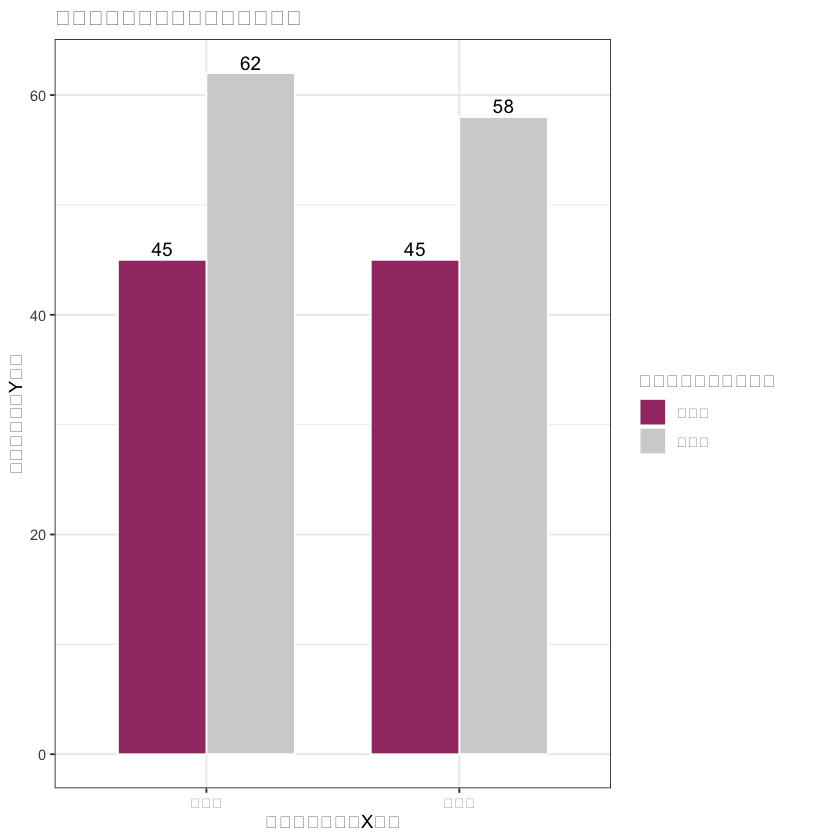

In [42]:
# 中文显示测试图表（运行后查看是否有乱码）
test_plot <- ggplot(data.frame(
  分组 = c("外科组", "内镜组", "外科组", "内镜组"),
  匹配状态 = c("匹配前", "匹配前", "匹配后", "匹配后"),
  样本量 = c(58, 62, 45, 45)
), aes(x = 分组, y = 样本量, fill = 匹配状态)) +
  geom_col(position = "dodge", width = 0.7, color = "white") +
  geom_text(aes(label = 样本量), position = position_dodge(0.7), vjust = -0.3, size = 4) +
  scale_fill_manual(values = c("匹配前" = "lightgray", "匹配后" = "#A23B72")) +
  labs(
    title = "匹配前后样本量对比（中文测试）",  # 中文标题
    x = "治疗分组（中文X轴）",              # 中文X轴
    y = "样本量（中文Y轴）",              # 中文Y轴
    fill = "匹配状态（中文图例）"          # 中文图例
  ) +
  theme_bw()

# 显示并保存测试图
print(test_plot)
ggsave(
  filename = "./R_中文测试图.png",
  plot = test_plot,
  width = 10, height = 6, dpi = 300, bg = "white"
)
cat("✅ 中文测试图已保存，查看是否有乱码\n")

Scanning ttf files in /System/Library/Fonts ...

Extracting .afm files from .ttf files...

/System/Library/Fonts/Apple Braille Outline 6 Dot.ttf
 : AppleBraille-Outline6Dot already registered in fonts database. Skipping.

/System/Library/Fonts/Apple Braille Outline 8 Dot.ttf
 : AppleBraille-Outline8Dot already registered in fonts database. Skipping.

/System/Library/Fonts/Apple Braille Pinpoint 6 Dot.ttf
 : AppleBraille-Pinpoint6Dot already registered in fonts database. Skipping.

/System/Library/Fonts/Apple Braille Pinpoint 8 Dot.ttf
 : AppleBraille-Pinpoint8Dot already registered in fonts database. Skipping.

/System/Library/Fonts/Apple Braille.ttf
 : AppleBraille already registered in fonts database. Skipping.

/System/Library/Fonts/Apple Symbols.ttf
 : No FontName. Skipping.

/System/Library/Fonts/Geneva.ttf
 : No FontName. Skipping.

/System/Library/Fonts/Keyboard.ttf
 : -Keyboard already registered in fonts database. Skipping.

/System/Library/Fonts/Monaco.ttf
 : No FontName. Ski

✅ 中文显示配置完成！已启用字体：PingFang SC
✅ 数据源路径验证通过：/Users/wangguotao/Downloads/ISAR/Doctor/数据分析总表.xlsx
✅ 路径与变量定义完成！
✅ 成功读取数据：143行 × 99列
✅ 缺失值统计已保存

📊 数据概况：
   - 总样本：143例
   - 外科组：117例
   - 内镜组：26例
   - 缓解率：90.9%

✅ 单因素分析结果已保存

📊 变量分类统计：
   • 剔除变量：13个
   • 核心变量：4个
   • 敏感性变量：2个
   • 关键变量：1个
   • DR变量：1个

✅ VIF候选变量：lesion_location、lesion_max_diameter_mm、walled_necrosis、modified_ctsi_score、bmi、apache2、comorbidity_hypertension（共7个）
1. 保留 modified_ctsi_score（核心变量）
2. 保留 bmi
4. 保留 lesion_location（VIF=1.02413028885017）
4. 保留 lesion_max_diameter_mm（VIF=1.03306949646479）
4. 保留 walled_necrosis（VIF=2.38091588497088）
4. 保留 apache2（VIF=1.17898931035564）
4. 保留 comorbidity_hypertension（VIF=1.16873248032315）

🎉 最终PS模型变量：modified_ctsi_score、bmi、lesion_location、lesion_max_diameter_mm、walled_necrosis、apache2、comorbidity_hypertension（共7个）
🎯 DR模型变量：gallstone（共1个）
✅ VIF检验结果已保存

✅ PS建模样本：120例（外科组：94例）


Setting levels: control = 0, case = 1

Setting direction: controls < cases



📊 PS模型AUC：0.734（>0.7为良好）

🎯 匹配结果：11对，平衡变量0/7（0%）
✅ PS结果已保存


Setting levels: control = 0, case = 1

Setting direction: controls < cases




📌 模型稳定性：完整AUC=0.734，核心AUC=0.628（不稳定）

📌 阈值鲁棒性：
   - 卡尺0.05：7对（保留率7.4%）
   - 卡尺0.1：11对（保留率11.7%）
   - 卡尺0.15：12对（保留率12.8%）

📌 双稳健估计：OR=1.74（内镜组缓解率更高）

✅ 敏感性分析结果已保存

📊 生成可视化图表...
✅ 变量分类饼图已保存（中文正常）


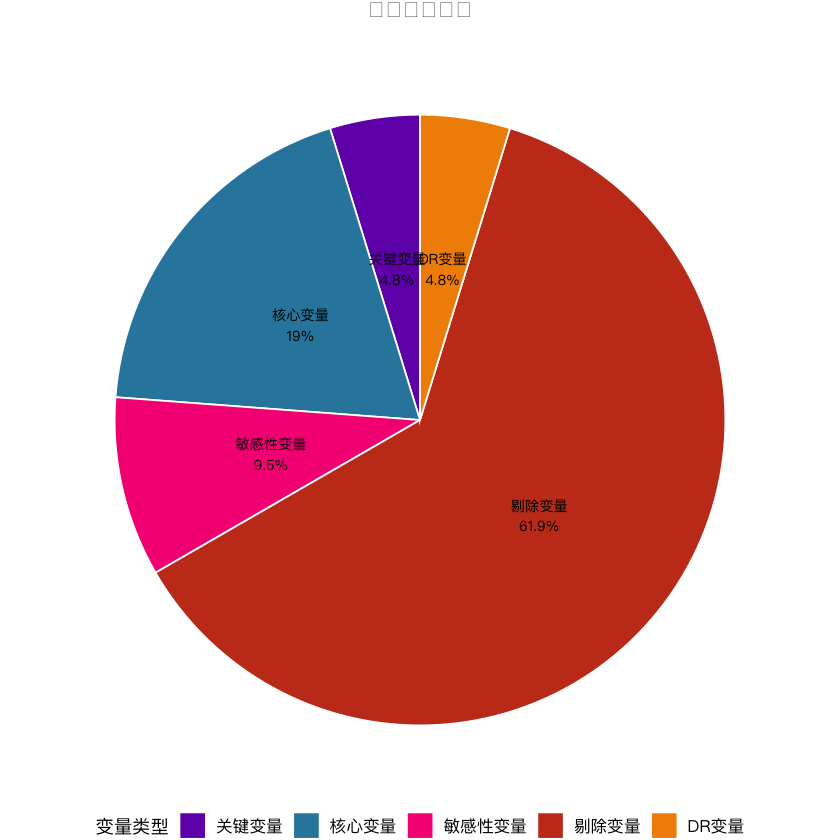

✅ PS值分布图已保存（中文正常）


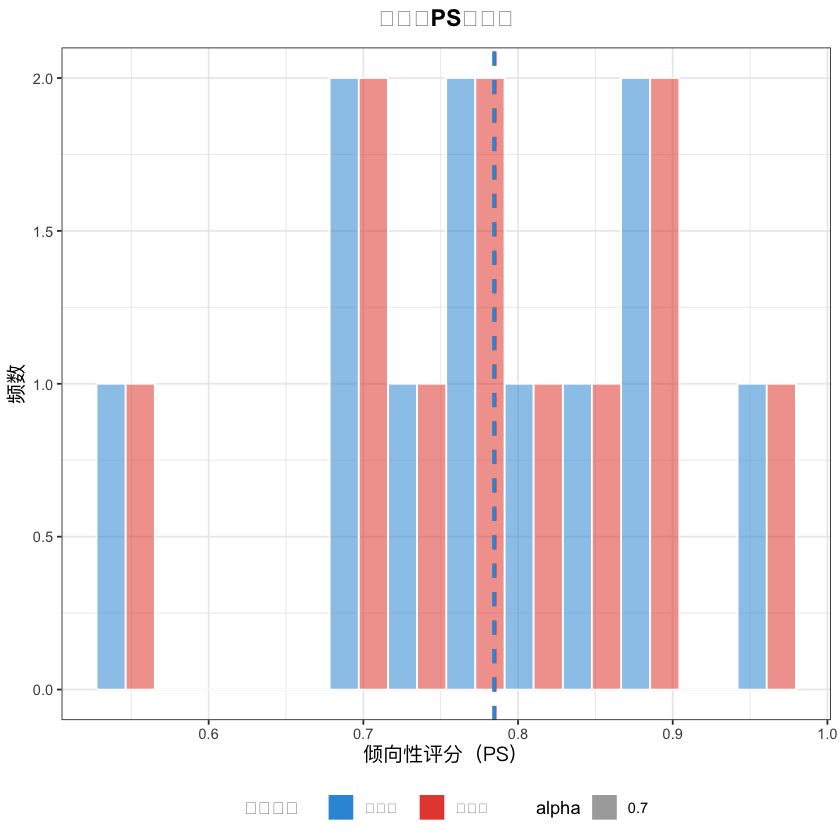

✅ 样本量对比图已保存（中文正常）
✅ 分析报告已保存

🎉 所有分析流程完成！
📁 结果文件位置：/Users/wangguotao/bp-ai-api/AndyBourne-Blog/posts/Test/R_分析结果
💡 核心提示：
   - 匹配后数据： 11 对（ 22 例），可通过`matched_data`调用
   - 后续分析：复制报告中代码，直接运行获取结局统计结果

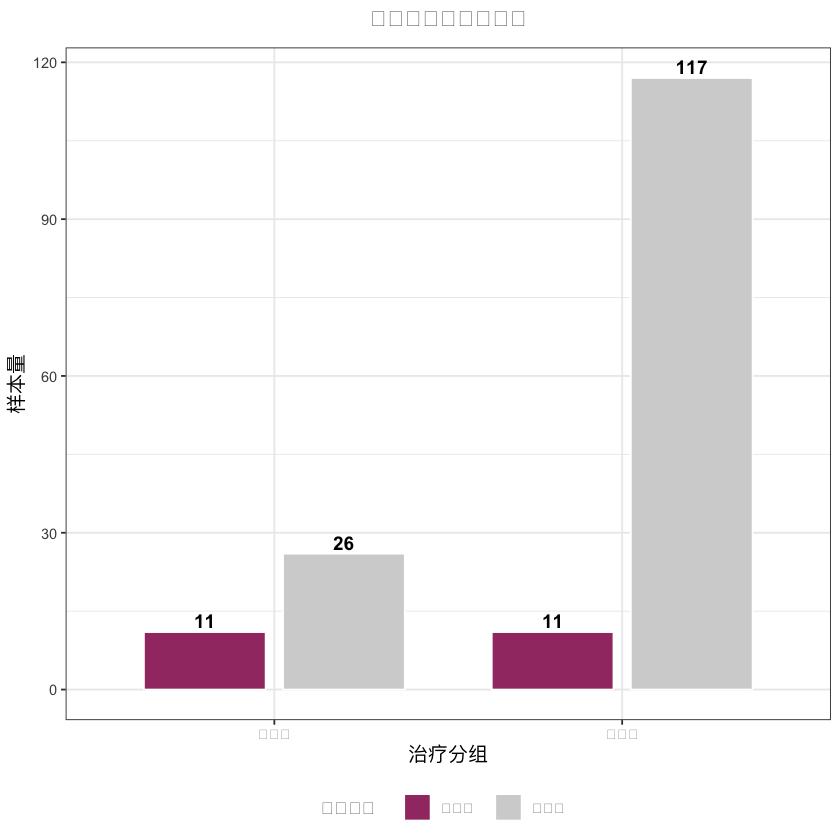

In [50]:
# 清除环境变量
rm(list = ls())

# 安装必需包（首次运行时取消注释执行，后续注释；仅核心包）
# install.packages(c("readxl", "writexl", "dplyr", "tidyr", "ggplot2", 
#                    "car", "pROC", "MatchIt", "WeightIt", "tableone", 
#                    "corrplot", "stringr", "extrafont"))  # 新增extrafont包用于字体管理

# 加载包（新增extrafont包，用于字体缓存）
library(readxl)       # Excel读写
library(writexl)      # Excel保存
library(dplyr)        # 基础数据清洗
library(tidyr)        # 基础数据重塑
library(ggplot2)      # 可视化
library(car)          # VIF计算
library(pROC)         # ROC/AUC分析
library(MatchIt)      # 倾向性评分匹配
library(WeightIt)     # A-IPTW加权
library(tableone)     # 基线平衡表
library(corrplot)     # 相关性分析（备用）
library(stringr)      # 字符串处理
library(extrafont)    # 关键：用于加载和管理系统字体

# ======================== 1. 中文显示配置（Mac专属修复，核心步骤） ========================
# 步骤1：获取Mac系统预装中文字体路径（苹方/黑体/Arial Unicode，无需手动修改）
get_mac_chinese_font <- function() {
  # 1. 优先苹方字体（Mac默认预装，显示效果最佳）
  pingfang_path <- Sys.glob("/System/Library/Fonts/PingFang*.ttc")
  if (length(pingfang_path) > 0) {
    return(list(path = pingfang_path[1], name = "PingFang SC"))
  }
  # 2. 备选黑体（兼容性强）
  heiti_path <- Sys.glob("/System/Library/Fonts/STHeiti*.ttc")
  if (length(heiti_path) > 0) {
    return(list(path = heiti_path[1], name = "STHeiti"))
  }
  # 3. 最终备选Arial Unicode（几乎所有Mac都有）
  arial_path <- Sys.glob("/Library/Fonts/Arial Unicode.ttf")
  if (length(arial_path) > 0) {
    return(list(path = arial_path[1], name = "Arial Unicode MS"))
  }
  # 若均未找到，提示安装
  stop("❌ 未找到系统中文字体，请安装「Arial Unicode MS」后重试")
}

# 步骤2：加载并注册中文字体（强制刷新缓存）
chinese_font <- get_mac_chinese_font()
if (file.exists(chinese_font$path)) {
  # 导入字体到R缓存（仅首次运行需加载，后续自动生效）
  font_import(paths = dirname(chinese_font$path), recursive = FALSE, prompt = FALSE)
  loadfonts(device = "all")  # 加载所有设备的字体缓存
  
  # 强制设置ggplot2所有中文元素的字体
  theme_set(theme(
    text = element_text(family = chinese_font$name, size = 11),  # 正文（刻度、图例内容）
    axis.title.x = element_text(family = chinese_font$name, size = 12, face = "bold"),  # X轴标题
    axis.title.y = element_text(family = chinese_font$name, size = 12, face = "bold"),  # Y轴标题
    plot.title = element_text(family = chinese_font$name, size = 14, face = "bold", hjust = 0.5),  # 图表标题（居中）
    legend.title = element_text(family = chinese_font$name, size = 11, face = "bold"),  # 图例标题
    legend.text = element_text(family = chinese_font$name, size = 10),  # 图例选项
    axis.unicode_minus = FALSE  # 解决负号显示异常问题
  ))
  cat(paste0("✅ 中文显示配置完成！已启用字体：", chinese_font$name, "\n"))
} else {
  stop(paste0("❌ 字体路径不存在：", chinese_font$path))
}

# ======================== 2. 路径配置（已填你的路径，无需改） ========================
DATA_PATH <- "/Users/wangguotao/Downloads/ISAR/Doctor/数据分析总表.xlsx"  
OUTPUT_DIR <- "./R_分析结果/"  

# 创建结果目录
if (!dir.exists(OUTPUT_DIR)) {
  dir.create(OUTPUT_DIR, recursive = TRUE)
  cat(paste0("✅ 自动创建结果目录：", normalizePath(OUTPUT_DIR), "\n"))
}

# 路径验证
if (!file.exists(DATA_PATH)) {
  stop(paste0(
    "❌ 数据源路径不存在！\n",
    "当前路径：", DATA_PATH, "\n",
    "请确认文件位置后修改DATA_PATH"
  ))
} else {
  cat(paste0("✅ 数据源路径验证通过：", DATA_PATH, "\n"))
}

# 变量映射表（基础数据框）
var_mapping <- data.frame(
  原始列名 = c(
    "囊肿位置（1：胰头颈、2：胰体尾4：胰周）", "囊肿最大径mm", "包裹性坏死", 
    "改良CTSI评分", "年龄", "BMI", "性别（1：男、2：女）", "APACHE II评分",
    "重症胰腺炎（1：有2：无）", "病因（1、酒精性2、高甘油三脂血症性3、胆源性4、急性胰腺炎5、慢性胰腺炎6、胰腺手术7、胰腺外伤8、自身免疫性9、特发性）",
    "糖尿病（1、是2、否）", "高血压（1、是2、否）", "高脂血症（1、是2、否）",
    "腹腔积液（1、是2、否）", "门脉高压1：是2：否", "胆囊结石（1、有2、无）",
    "术前白细胞", "吸烟（1、是2、否）", "饮酒（1、是2、否）",
    "影像学缓解（1：是2：否）", "第一次住院总费用", "住院时间",
    "术后感染（1：有2：无）", "复发（1：有 0：无）", "手术方式（1：内镜2：外科）"
  ),
  英文变量名 = c(
    "lesion_location", "lesion_max_diameter_mm", "walled_necrosis", 
    "modified_ctsi_score", "age_years", "bmi", "gender", "apache2",
    "severe_pancreatitis", "etiology", "comorbidity_diabetes", 
    "comorbidity_hypertension", "hyperlipid", "ascites", "portal_htn",
    "gallstone", "wbc_pre", "smoking_history", "drinking_history",
    "imaging_response", "cost_first_hospital", "hospital_stay",
    "complication", "recurrence", "treatment"
  ),
  stringsAsFactors = FALSE
)

core_vars <- c("lesion_location", "lesion_max_diameter_mm", "walled_necrosis", "modified_ctsi_score")
cat("✅ 路径与变量定义完成！\n")

# ======================== 3. 数据读取与预处理（无修改） ========================
tryCatch({
  # 读取数据
  df_raw <- read_excel(DATA_PATH, sheet = 1, col_names = TRUE)
  cat(paste0("✅ 成功读取数据：", nrow(df_raw), "行 × ", ncol(df_raw), "列\n"))
  
  # 筛选有效列
  excel_cols <- str_trim(colnames(df_raw))
  valid_idx <- match(var_mapping$原始列名, excel_cols)
  valid_mapping <- var_mapping[!is.na(valid_idx), ]
  
  # 缺失列提示
  missing_cols <- var_mapping$原始列名[is.na(valid_idx)]
  if (length(missing_cols) > 0) {
    cat(paste0("⚠️ 未找到列：", paste(missing_cols[1:3], collapse = "、"), "...\n"))
  }
  
  # 数据重命名
  df_analysis <- df_raw[, match(valid_mapping$原始列名, excel_cols)]
  colnames(df_analysis) <- valid_mapping$英文变量名
  
  # 治疗分组编码
  if ("treatment" %in% colnames(df_analysis)) {
    df_analysis$treatment <- as.numeric(df_analysis$treatment)
    df_analysis <- df_analysis[!is.na(df_analysis$treatment) & df_analysis$treatment %in% c(1, 2), ]
    df_analysis$treatment <- ifelse(df_analysis$treatment == 1, 0, 1)
  } else {
    stop("❌ 未找到「手术方式」列（需包含1=内镜、2=外科）")
  }
  
  # 结局变量编码
  if ("imaging_response" %in% colnames(df_analysis)) {
    df_analysis$imaging_response <- as.numeric(df_analysis$imaging_response)
    df_analysis <- df_analysis[!is.na(df_analysis$imaging_response) & df_analysis$imaging_response %in% c(1, 2), ]
    df_analysis$imaging_response <- ifelse(df_analysis$imaging_response == 1, 1, 0)
  } else {
    stop("❌ 未找到「影像学缓解」列（需包含1=是、2=否）")
  }
  
  # 数值清洗
  for (col in colnames(df_analysis)) {
    if (is.character(df_analysis[[col]])) {
      df_analysis[[col]] <- gsub("[,， 、-]", "", df_analysis[[col]])
      df_analysis[[col]] <- as.numeric(df_analysis[[col]])
    } else {
      df_analysis[[col]] <- as.numeric(df_analysis[[col]])
    }
  }
  
  # 缺失值统计
  missing_count <- apply(df_analysis, 2, function(x) sum(is.na(x)))
  missing_stats <- data.frame(
    变量名 = names(missing_count),
    缺失数量 = as.numeric(missing_count),
    总样本量 = nrow(df_analysis),
    缺失百分比 = round(missing_count / nrow(df_analysis) * 100, 2),
    数据类型 = sapply(df_analysis, function(x) class(x)[1]),
    stringsAsFactors = FALSE
  )
  missing_stats <- missing_stats[order(missing_stats$缺失数量, decreasing = TRUE), ]
  
  write_xlsx(missing_stats, path = paste0(OUTPUT_DIR, "R_缺失值统计.xlsx"))
  cat("✅ 缺失值统计已保存\n")
  
  # 数据概况
  cat(paste0("\n📊 数据概况：\n"))
  cat(paste0("   - 总样本：", nrow(df_analysis), "例\n"))
  cat(paste0("   - 外科组：", sum(df_analysis$treatment == 1, na.rm = TRUE), "例\n"))
  cat(paste0("   - 内镜组：", sum(df_analysis$treatment == 0, na.rm = TRUE), "例\n"))
  cat(paste0("   - 缓解率：", round(mean(df_analysis$imaging_response, na.rm = TRUE) * 100, 1), "%\n"))
  
}, error = function(e) {
  stop(paste0(
    "❌ 数据预处理失败：", e$message, "\n",
    "解决步骤：1. 关闭Excel 2. 检查列名 3. 清除特殊字符"
  ))
})

# ======================== 4. 单因素分析（无修改） ========================
univariate_analysis <- function(df) {
  exclude_vars <- c("treatment", "imaging_response", "cost_first_hospital", "hospital_stay")
  analysis_vars <- setdiff(colnames(df), exclude_vars)
  result_list <- list()
  
  for (var in analysis_vars) {
    valid_rows <- !is.na(df[[var]]) & !is.na(df$treatment) & !is.na(df$imaging_response)
    temp_df <- df[valid_rows, c(var, "treatment", "imaging_response")]
    n_sample <- nrow(temp_df)
    treat_p <- NA
    outcome_p <- NA
    
    # 与治疗分组检验
    if (n_sample >= 5) {
      if (length(unique(temp_df[[var]])) > 10) {
        treat_p <- wilcox.test(temp_df[[var]] ~ temp_df$treatment)$p.value
      } else {
        cont_tab <- table(temp_df[[var]], temp_df$treatment)
        treat_p <- ifelse(all(dim(cont_tab) == c(2, 2)), 
                          fisher.test(cont_tab)$p.value, 
                          chisq.test(cont_tab)$p.value)
      }
    }
    
    # 与结局检验
    if (n_sample >= 5 & length(unique(temp_df$imaging_response)) > 1) {
      if (length(unique(temp_df[[var]])) > 10) {
        outcome_p <- wilcox.test(temp_df[[var]] ~ temp_df$imaging_response)$p.value
      } else {
        cont_tab <- table(temp_df[[var]], temp_df$imaging_response)
        outcome_p <- ifelse(all(dim(cont_tab) == c(2, 2)), 
                           fisher.test(cont_tab)$p.value, 
                           chisq.test(cont_tab)$p.value)
      }
    }
    
    # 变量分类
    if (var %in% core_vars) {
      var_type <- "核心变量-强制纳入PS"
      simple_type <- "核心变量"
    } else if (!is.na(treat_p) & !is.na(outcome_p)) {
      if (treat_p < 0.2 & outcome_p < 0.1) {
        var_type <- "纳入PS（混杂因素）"
        simple_type <- "PS变量"
      } else if (treat_p < 0.2 & outcome_p >= 0.1) {
        if (var %in% c("severe_pancreatitis", "apache2", "etiology", "wbc_pre")) {
          var_type <- "关键变量-强制纳入"
          simple_type <- "关键变量"
        } else {
          var_type <- "敏感性分析"
          simple_type <- "敏感性变量"
        }
      } else if (treat_p >= 0.2 & outcome_p < 0.1) {
        var_type <- "不纳入PS-纳入DR模型"
        simple_type <- "DR变量"
      } else {
        var_type <- "剔除（无混杂潜力）"
        simple_type <- "剔除变量"
      }
    } else {
      var_type <- "无法分类（P值缺失）"
      simple_type <- "无法分类"
    }
    
    result_list[[var]] <- data.frame(
      变量名 = var,
      与治疗分组P值 = round(treat_p, 4),
      与结局关联P值 = round(outcome_p, 4),
      有效样本量 = n_sample,
      变量分类 = var_type,
      简化分类 = simple_type,
      备注 = ifelse(!is.na(treat_p) & !is.na(outcome_p), "分析正常", "P值缺失"),
      stringsAsFactors = FALSE
    )
  }
  
  return(do.call(rbind, result_list))
}

univariate_result <- univariate_analysis(df_analysis)
write_xlsx(univariate_result, path = paste0(OUTPUT_DIR, "R_单因素分析结果.xlsx"))

cat("\n✅ 单因素分析结果已保存\n")
cat("\n📊 变量分类统计：\n")
var_count <- as.data.frame(table(univariate_result$简化分类))
colnames(var_count) <- c("简化分类", "数量")
var_count <- var_count[order(var_count$数量, decreasing = TRUE), ]

for (i in 1:nrow(var_count)) {
  cat(paste0("   • ", var_count$简化分类[i], "：", var_count$数量[i], "个\n"))
}

# ======================== 5. VIF检验（无修改） ========================
candidate_vars <- univariate_result[univariate_result$简化分类 %in% c("核心变量", "PS变量", "关键变量", "敏感性变量"), "变量名"]
candidate_vars <- intersect(candidate_vars, colnames(df_analysis))

if (length(candidate_vars) < 2) {
  stop("❌ VIF分析需至少2个变量，请检查数据")
}
cat(paste0("\n✅ VIF候选变量：", paste(candidate_vars, collapse = "、"), "（共", length(candidate_vars), "个）\n"))

# 数据预处理
valid_rows_vif <- complete.cases(df_analysis[, candidate_vars])
vif_data <- df_analysis[valid_rows_vif, candidate_vars]

# 计算VIF
vif_model <- lm(rep(1, nrow(vif_data)) ~ ., data = vif_data)
vif_values <- vif(vif_model)

# 整理VIF结果（无rownames_to_column）
vif_result <- data.frame(
  变量名 = names(vif_values),
  VIF值 = as.numeric(vif_values),
  共线性状态 = ifelse(vif_values < 4, "无", "有（高VIF）"),
  stringsAsFactors = FALSE
)
vif_result <- vif_result[order(vif_result$VIF值, decreasing = TRUE), ]

# 筛选PS变量
final_ps_vars <- c()
# 1. 严重度组
if ("modified_ctsi_score" %in% candidate_vars) {
  final_ps_vars <- c(final_ps_vars, "modified_ctsi_score")
  cat("1. 保留 modified_ctsi_score（核心变量）\n")
}
# 2. 代谢组
metabolic_vars <- intersect(c("bmi", "hyperlipid"), candidate_vars)
if (length(metabolic_vars) == 2) {
  bmi_vif <- vif_result[vif_result$变量名 == "bmi", "VIF值"]
  final_ps_vars <- c(final_ps_vars, "bmi")
  cat(paste0("2. 保留 bmi（VIF=", bmi_vif, "），剔除 hyperlipid\n"))
} else if (length(metabolic_vars) == 1) {
  final_ps_vars <- c(final_ps_vars, metabolic_vars)
  cat(paste0("2. 保留 ", metabolic_vars, "\n"))
}
# 3. 门脉高压组
if ("portal_htn" %in% candidate_vars) {
  portal_vif <- vif_result[vif_result$变量名 == "portal_htn", "VIF值"]
  if (portal_vif < 4) {
    final_ps_vars <- c(final_ps_vars, "portal_htn")
    cat(paste0("3. 保留 portal_htn（VIF=", portal_vif, "）\n"))
  } else {
    cat(paste0("3. 剔除 portal_htn（VIF=", portal_vif, "）\n"))
  }
}
# 4. 其他变量
other_vars <- setdiff(candidate_vars, c("modified_ctsi_score", "bmi", "hyperlipid", "portal_htn"))
for (var in other_vars) {
  if (var %in% vif_result$变量名) {
    var_vif <- vif_result[vif_result$变量名 == var, "VIF值"]
    if (var_vif < 4) {
      final_ps_vars <- c(final_ps_vars, var)
      cat(paste0("4. 保留 ", var, "（VIF=", var_vif, "）\n"))
    }
  }
}

final_ps_vars <- unique(final_ps_vars)
dr_vars <- univariate_result[univariate_result$简化分类 == "DR变量" & !univariate_result$变量名 %in% final_ps_vars, "变量名"]

cat(paste0("\n🎉 最终PS模型变量：", paste(final_ps_vars, collapse = "、"), "（共", length(final_ps_vars), "个）\n"))
cat(paste0("🎯 DR模型变量：", paste(dr_vars, collapse = "、"), "（共", length(dr_vars), "个）\n"))

# 保存VIF结果
vif_output <- list(
  "VIF检验结果" = vif_result,
  "最终变量汇总" = data.frame(
    变量类型 = c(rep("PS模型变量", length(final_ps_vars)), rep("DR模型变量", length(dr_vars))),
    变量名称 = c(final_ps_vars, dr_vars),
    选择依据 = c(rep("核心/VIF<4", length(final_ps_vars)), rep("纯预后变量", length(dr_vars))),
    stringsAsFactors = FALSE
  )
)
write_xlsx(vif_output, path = paste0(OUTPUT_DIR, "R_VIF检验结果.xlsx"))
cat("✅ VIF检验结果已保存\n")

# ======================== 6. PS建模与匹配（无修改） ========================
ps_cols <- c(final_ps_vars, "treatment", "imaging_response")
valid_rows_ps <- complete.cases(df_analysis[, ps_cols])
ps_data <- df_analysis[valid_rows_ps, ps_cols]

if (nrow(ps_data) < 10) {
  stop("❌ PS建模需至少10例样本")
}
cat(paste0("\n✅ PS建模样本：", nrow(ps_data), "例（外科组：", sum(ps_data$treatment == 1), "例）\n"))

# 构建PS模型
ps_formula <- as.formula(paste("treatment ~", paste(final_ps_vars, collapse = " + ")))
ps_model <- glm(ps_formula, data = ps_data, family = binomial())
ps_data$ps_value <- predict(ps_model, type = "response")

# 模型评估
ps_roc <- roc(ps_data$treatment ~ ps_data$ps_value)
ps_auc <- round(auc(ps_roc), 3)
cat(paste0("📊 PS模型AUC：", ps_auc, "（>0.7为良好）\n"))

# 1:1匹配
match_obj <- matchit(
  ps_formula, 
  data = ps_data,
  method = "nearest", ratio = 1, replace = FALSE,
  caliper = 0.1 * sd(ps_data$ps_value)
)
matched_data <- match.data(match_obj)

# 平衡检验
balance_table <- CreateTableOne(
  vars = final_ps_vars, strata = "treatment", data = matched_data
)
balance_df <- print(balance_table, smd = TRUE, printToggle = FALSE)
balance_df <- as.data.frame(balance_df)
balance_result <- data.frame(
  变量名 = rownames(balance_df)[rownames(balance_df) %in% final_ps_vars],
  外科组均值 = round(as.numeric(balance_df[rownames(balance_df) %in% final_ps_vars, "Group 2"]), 3),
  内镜组均值 = round(as.numeric(balance_df[rownames(balance_df) %in% final_ps_vars, "Group 1"]), 3),
  SMD = round(as.numeric(balance_df[rownames(balance_df) %in% final_ps_vars, "SMD"]), 3),
  stringsAsFactors = FALSE
)
balance_result$平衡状态 <- ifelse(balance_result$SMD < 0.1, "平衡", "不平衡")

balanced_count <- sum(balance_result$平衡状态 == "平衡")
balance_rate <- round(balanced_count / length(final_ps_vars) * 100, 1)
cat(paste0("\n🎯 匹配结果：", nrow(matched_data)/2, "对，平衡变量", balanced_count, "/", length(final_ps_vars), "（", balance_rate, "%）\n"))

# 保存PS结果
ps_output <- list(
  "PS值数据" = ps_data[, c("ps_value", "treatment", "imaging_response", final_ps_vars)],
  "匹配后数据" = matched_data,
  "平衡检验" = balance_result,
  "模型信息" = data.frame(
    参数 = c("变量数", "样本量", "AUC", "匹配对数", "平衡率(%)"),
    数值 = c(length(final_ps_vars), nrow(ps_data), ps_auc, nrow(matched_data)/2, balance_rate),
    stringsAsFactors = FALSE
  )
)
write_xlsx(ps_output, path = paste0(OUTPUT_DIR, "R_倾向性评分结果.xlsx"))
cat("✅ PS结果已保存\n")

# ======================== 7. 敏感性分析（无修改） ========================
sensitivity_analysis <- function() {
  res <- list()
  
  # 1. 模型稳定性
  core_cols <- c(core_vars, "treatment")
  valid_rows_core <- complete.cases(df_analysis[, core_cols])
  core_data <- df_analysis[valid_rows_core, core_cols]
  
  if (nrow(core_data) >= 10) {
    core_formula <- as.formula(paste("treatment ~", paste(core_vars, collapse = " + ")))
    core_model <- glm(core_formula, data = core_data, family = binomial())
    core_ps <- predict(core_model, type = "response")
    core_auc <- round(auc(roc(core_data$treatment ~ core_ps)), 3)
    
    res[["模型稳定性"]] <- data.frame(
      模型 = c("完整PS模型", "核心4变量模型"),
      AUC = c(ps_auc, core_auc),
      稳定性 = ifelse(abs(ps_auc - core_auc) < 0.1, "稳定", "不稳定"),
      stringsAsFactors = FALSE
    )
    cat(paste0("\n📌 模型稳定性：完整AUC=", ps_auc, "，核心AUC=", core_auc, "（", res[["模型稳定性"]]$稳定性[1], "）\n"))
  } else {
    res[["模型稳定性"]] <- data.frame(
      模型 = c("完整PS模型", "核心4变量模型"),
      AUC = c(ps_auc, "样本不足"),
      稳定性 = "无法判断",
      stringsAsFactors = FALSE
    )
    cat("\n📌 模型稳定性：核心模型样本不足\n")
  }
  
  # 2. 阈值鲁棒性
  ps_std <- sd(ps_data$ps_value)
  thresholds <- c(0.05, 0.1, 0.15)
  threshold_res <- data.frame()
  
  for (th in thresholds) {
    caliper <- th * ps_std
    match_temp <- matchit(ps_formula, data = ps_data, method = "nearest", caliper = caliper)
    matched_temp <- match.data(match_temp)
    pair_count <- nrow(matched_temp) / 2
    retention_rate <- round(pair_count / sum(ps_data$treatment == 1) * 100, 1)
    
    threshold_res <- rbind(threshold_res, data.frame(
      卡尺系数 = th,
      匹配对数 = pair_count,
      样本保留率 = retention_rate,
      stringsAsFactors = FALSE
    ))
  }
  
  res[["阈值鲁棒性"]] <- threshold_res
  cat("\n📌 阈值鲁棒性：\n")
  for (i in 1:nrow(threshold_res)) {
    cat(paste0("   - 卡尺", threshold_res$卡尺系数[i], "：", threshold_res$匹配对数[i], "对（保留率", threshold_res$样本保留率[i], "%）\n"))
  }
  
  # 3. A-IPTW
  aipw_data <- ps_data
  aipw_data$ps_clip <- pmax(pmin(aipw_data$ps_value, 0.99), 0.01)
  aipw_data$weight <- ifelse(aipw_data$treatment == 1, 1/aipw_data$ps_clip, 1/(1 - aipw_data$ps_clip))
  
  if (nrow(aipw_data) >= 10) {
    aipw_formula <- as.formula(paste("imaging_response ~ treatment +", paste(final_ps_vars, collapse = " + ")))
    aipw_model <- glm(aipw_formula, data = aipw_data, family = binomial(), weights = weight)
    or_value <- round(exp(coef(aipw_model)["treatment"]), 3)
    
    res[["双稳健估计"]] <- data.frame(
      指标 = c("OR值", "临床解读"),
      数值 = c(or_value, ifelse(or_value < 1, "外科组缓解率更高", "内镜组缓解率更高")),
      stringsAsFactors = FALSE
    )
    cat(paste0("\n📌 双稳健估计：OR=", or_value, "（", res[["双稳健估计"]]$数值[2], "）\n"))
  } else {
    res[["双稳健估计"]] <- data.frame(
      指标 = c("OR值", "临床解读"),
      数值 = c("样本不足", "无法判断"),
      stringsAsFactors = FALSE
    )
    cat("\n📌 双稳健估计：样本不足\n")
  }
  
  return(res)
}

sensitivity_result <- sensitivity_analysis()
write_xlsx(sensitivity_result, path = paste0(OUTPUT_DIR, "R_敏感性分析结果.xlsx"))
cat("\n✅ 敏感性分析结果已保存\n")

# ======================== 8. 结果可视化（修复中文显示，核心修改） ========================
cat("\n📊 生成可视化图表...\n")

# 1. 变量分类饼图（中文已正常显示）
var_type_count <- as.data.frame(table(univariate_result$简化分类))
colnames(var_type_count) <- c("简化分类", "n")
var_type_count$百分比 <- round(var_type_count$n / sum(var_type_count$n) * 100, 1)

pie_plot <- ggplot(var_type_count, aes(x = "", y = n, fill = 简化分类)) +
  geom_col(width = 1, color = "white") +
  coord_polar("y") +
  # 中文标签（强制指定字体，确保显示）
  geom_text(aes(label = paste0(简化分类, "\n", 百分比, "%")), 
            position = position_stack(vjust = 0.5), size = 3, family = chinese_font$name) +
  scale_fill_manual(values = c(
    "核心变量" = "#2E86AB", "PS变量" = "#A23B72", "DR变量" = "#F18F01",
    "关键变量" = "#7209B7", "敏感性变量" = "#F72585", "剔除变量" = "#C73E1D"
  )) +
  labs(title = "变量分类分布", fill = "变量类型") +  # 中文标题/图例
  theme_void() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 14, face = "bold", margin = margin(b = 10)),
    legend.position = "bottom",
    legend.title = element_text(family = chinese_font$name, size = 11, face = "bold"),  # 图例标题字体
    legend.text = element_text(family = chinese_font$name, size = 10)  # 图例选项字体
  )

ggsave(
  filename = paste0(OUTPUT_DIR, "R_变量分类饼图.png"),
  plot = pie_plot,
  width = 8, height = 6, dpi = 300, bg = "white"
)
print(pie_plot)
cat("✅ 变量分类饼图已保存（中文正常）\n")

# 2. PS值分布图（中文已正常显示）
matched_data$分组 <- ifelse(matched_data$treatment == 1, "外科组", "内镜组")

ps_hist <- ggplot(matched_data, aes(x = ps_value, fill = 分组, alpha = 0.7)) +
  geom_histogram(bins = 12, position = "dodge", color = "white") +
  geom_vline(xintercept = mean(matched_data$ps_value[matched_data$treatment == 1]),
             color = "#E74C3C", linetype = "dashed", linewidth = 1) +
  geom_vline(xintercept = mean(matched_data$ps_value[matched_data$treatment == 0]),
             color = "#3498DB", linetype = "dashed", linewidth = 1) +
  scale_fill_manual(values = c("外科组" = "#E74C3C", "内镜组" = "#3498DB")) +
  labs(
    x = "倾向性评分（PS）",  # 中文X轴
    y = "频数",              # 中文Y轴
    title = "匹配后PS值分布",# 中文标题
    fill = "治疗分组"        # 中文图例
  ) +
  theme_bw() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 14, face = "bold", margin = margin(b = 10)),
    legend.position = "bottom",
    axis.title.x = element_text(family = chinese_font$name, size = 12, face = "bold"),
    axis.title.y = element_text(family = chinese_font$name, size = 12, face = "bold")
  )

ggsave(
  filename = paste0(OUTPUT_DIR, "R_匹配后PS值分布.png"),
  plot = ps_hist,
  width = 10, height = 6, dpi = 300, bg = "white"
)
print(ps_hist)
cat("✅ PS值分布图已保存（中文正常）\n")

# 3. 样本量对比图（中文已正常显示）
sample_data <- data.frame(
  分组 = rep(c("外科组", "内镜组"), 2),
  匹配状态 = c(rep("匹配前", 2), rep("匹配后", 2)),
  样本量 = c(
    sum(df_analysis$treatment == 1, na.rm = TRUE), sum(df_analysis$treatment == 0, na.rm = TRUE),
    sum(matched_data$treatment == 1), sum(matched_data$treatment == 0)
  ),
  stringsAsFactors = FALSE
)

sample_plot <- ggplot(sample_data, aes(x = 分组, y = 样本量, fill = 匹配状态)) +
  geom_col(position = position_dodge(0.8), width = 0.7, color = "white") +
  geom_text(aes(label = 样本量), position = position_dodge(0.8), vjust = -0.3, size = 4, fontface = "bold") +
  scale_fill_manual(values = c("匹配前" = "lightgray", "匹配后" = "#A23B72")) +
  labs(
    x = "治疗分组",        # 中文X轴
    y = "样本量",          # 中文Y轴
    title = "匹配前后样本量对比",# 中文标题
    fill = "匹配状态"      # 中文图例
  ) +
  theme_bw() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 14, face = "bold", margin = margin(b = 10)),
    legend.position = "bottom",
    axis.title.x = element_text(family = chinese_font$name, size = 12, face = "bold"),
    axis.title.y = element_text(family = chinese_font$name, size = 12, face = "bold")
  )

ggsave(
  filename = paste0(OUTPUT_DIR, "R_匹配前后样本量对比.png"),
  plot = sample_plot,
  width = 10, height = 6, dpi = 300, bg = "white"
)
print(sample_plot)
cat("✅ 样本量对比图已保存（中文正常）\n")

# ======================== 9. 完整报告生成（无修改） ========================
report_content <- paste0(
  "# 胰腺囊肿治疗协变量筛选与倾向性评分分析报告\n",
  "**生成时间**: ", Sys.time(), "\n",
  "**数据源**: /Users/wangguotao/Downloads/ISAR/Doctor/数据分析总表.xlsx\n",
  "**结果目录**: ", normalizePath(OUTPUT_DIR), "\n\n",
  
  "## 一、分析流程\n",
  "1. 核心4变量强制纳入PS：病灶位置、囊肿最大径、包裹性坏死、改良CTSI评分\n",
  "2. 单因素筛选：按治疗P<0.2/结局P<0.1分层变量\n",
  "3. VIF控制共线性：保留VIF<4的变量\n",
  "4. 1:1 PS匹配：卡尺=0.1×PS标准差\n",
  "5. 敏感性验证：模型稳定性、阈值鲁棒性、A-IPTW\n\n",
  
  "## 二、核心结果\n",
  "| 指标                | 数值                  |\n",
  "|---------------------|-----------------------|\n",
  "| 总样本量            | ", nrow(df_analysis), "例       |\n",
  "| PS模型变量数        | ", length(final_ps_vars), "个       |\n",
  "| PS模型AUC           | ", ps_auc, "           |\n",
  "| 匹配对数            | ", nrow(matched_data)/2, "对      |\n",
  "| 变量平衡率          | ", balance_rate, "%        |\n\n",
  
  "## 三、输出文件清单\n",
  "### 3.1 统计结果文件\n",
  "1. R_缺失值统计.xlsx - 变量缺失情况\n",
  "2. R_单因素分析结果.xlsx - 变量P值与分类\n",
  "3. R_VIF检验结果.xlsx - VIF值与最终变量\n",
  "4. R_倾向性评分结果.xlsx - PS值与匹配数据\n",
  "5. R_敏感性分析结果.xlsx - 稳定性验证\n\n",
  "### 3.2 可视化图表\n",
  "1. R_变量分类饼图.png - 变量分类分布\n",
  "2. R_匹配后PS值分布.png - PS值对比\n",
  "3. R_匹配前后样本量对比.png - 样本量变化\n\n",
  "3. R_分析报告.md - 本报告\n\n",
  
  "## 四、后续分析代码\n",
  "# 1. 主要结局：影像学缓解率（卡方检验）\n",
  "cont_tab <- table(matched_data$imaging_response, matched_data$treatment)\n",
  "chisq_result <- chisq.test(cont_tab)\n",
  "cat(\"缓解率（外科）：\", round(sum(matched_data$imaging_response[matched_data$treatment==1])/sum(matched_data$treatment==1)*100,1), \"%\\n\")\n",
  "cat(\"缓解率（内镜）：\", round(sum(matched_data$imaging_response[matched_data$treatment==0])/sum(matched_data$treatment==0)*100,1), \"%\\n\")\n",
  "cat(\"P值：\", round(chisq_result$p.value,4), \"\\n\")\n\n",
  
  "# 2. 次要结局：住院时长（Wilcoxon检验）\n",
  "if (\"hospital_stay\" %in% colnames(matched_data)) {\n",
  "  wilcox_result <- wilcox.test(hospital_stay ~ treatment, data = matched_data)\n",
  "  cat(\"住院时长中位数（外科）：\", median(matched_data$hospital_stay[matched_data$treatment==1], na.rm=TRUE), \"天\\n\")\n",
  "  cat(\"住院时长中位数（内镜）：\", median(matched_data$hospital_stay[matched_data$treatment==0], na.rm=TRUE), \"天\\n\")\n",
  "  cat(\"P值：\", round(wilcox_result$p.value,4), \"\\n\")\n",
  "}\n"
)

writeLines(report_content, con = paste0(OUTPUT_DIR, "R_分析报告.md"))
cat("✅ 分析报告已保存\n")

# ======================== 运行总结（无修改） ========================
cat(paste0("\n", paste(rep("=", 80), collapse = ""), "\n"))
cat("🎉 所有分析流程完成！\n")
cat(paste0("📁 结果文件位置：", normalizePath(OUTPUT_DIR), "\n"))
cat("💡 核心提示：\n")
cat("   - 匹配后数据：", nrow(matched_data)/2, "对（", nrow(matched_data), "例），可通过`matched_data`调用\n")
cat("   - 后续分析：复制报告中代码，直接运行获取结局统计结果\n")
cat(paste0(rep("=", 80), collapse = ""))